# Comparativa de hardware entre runs

Vista panorámica de cómo se comporta el hardware (temperatura, potencia,
CPU, memoria) durante la inferencia de distintos modelos.

Cada columna del grid es un run. Esto permite comparar el régimen térmico,
el consumo de potencia y la carga de CPU/memoria entre modelos que corren
en la misma Raspberry Pi 5.

## Cómo usar este notebook

1. Coloca todos los runs en  (cada run en su propia subcarpeta).
2. *Run All*.

In [1]:
"""Carga todos los runs con hardware data."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "raw_runs"

assert DATA_ROOT.is_dir(), f"❌ No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
hw_runs = RunCollection(runs=[r for r in coll if r.has_hardware_data])
print(f"Runs cargados: {len(coll)} total, {len(hw_runs)} con hardware data.")
for r in hw_runs:
    print(f"  • {r.model_short} ({r.summary.inference_engine}) — "
          f"{len(r.hw_samples)} muestras, {len(r.prompts)} prompts")

Runs cargados: 12 total, 12 con hardware data.
  • ministral:q4_k_m (OLLAMA) — 25481 muestras, 15 prompts
  • Ministral-3-3B-Instruct-2512-Q4_K_M (LLAMA) — 22815 muestras, 15 prompts
  • llama3.2_3b:q4_k_m (OLLAMA) — 9832 muestras, 15 prompts
  • Llama-3.2-3B-Instruct-Q4_K_M (LLAMA) — 51009 muestras, 15 prompts
  • llama3.2_1b:q4_k_m (OLLAMA) — 3599 muestras, 15 prompts
  • Llama-3.2-1B-Instruct-Q4_K_M (LLAMA) — 20992 muestras, 15 prompts
  • granite:q4_k_m (OLLAMA) — 9700 muestras, 15 prompts
  • granite-4.0-h-micro-Q4_K_M (LLAMA) — 8585 muestras, 15 prompts
  • gemma:q4_k_m (OLLAMA) — 12128 muestras, 15 prompts
  • gemma-4.5B-3n-E2B-it-Q4_K_M (LLAMA) — 11167 muestras, 15 prompts
  • deepseek:q4_k_m (OLLAMA) — 9810 muestras, 15 prompts
  • DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M (LLAMA) — 36363 muestras, 15 prompts


## Temperatura a lo largo del run

Cada panel es un modelo. Se puede observar:
- Velocidad de calentamiento inicial (rampa).
- Temperatura de saturación (plateau).
- Si alcanza el umbral de throttling (~80 °C).

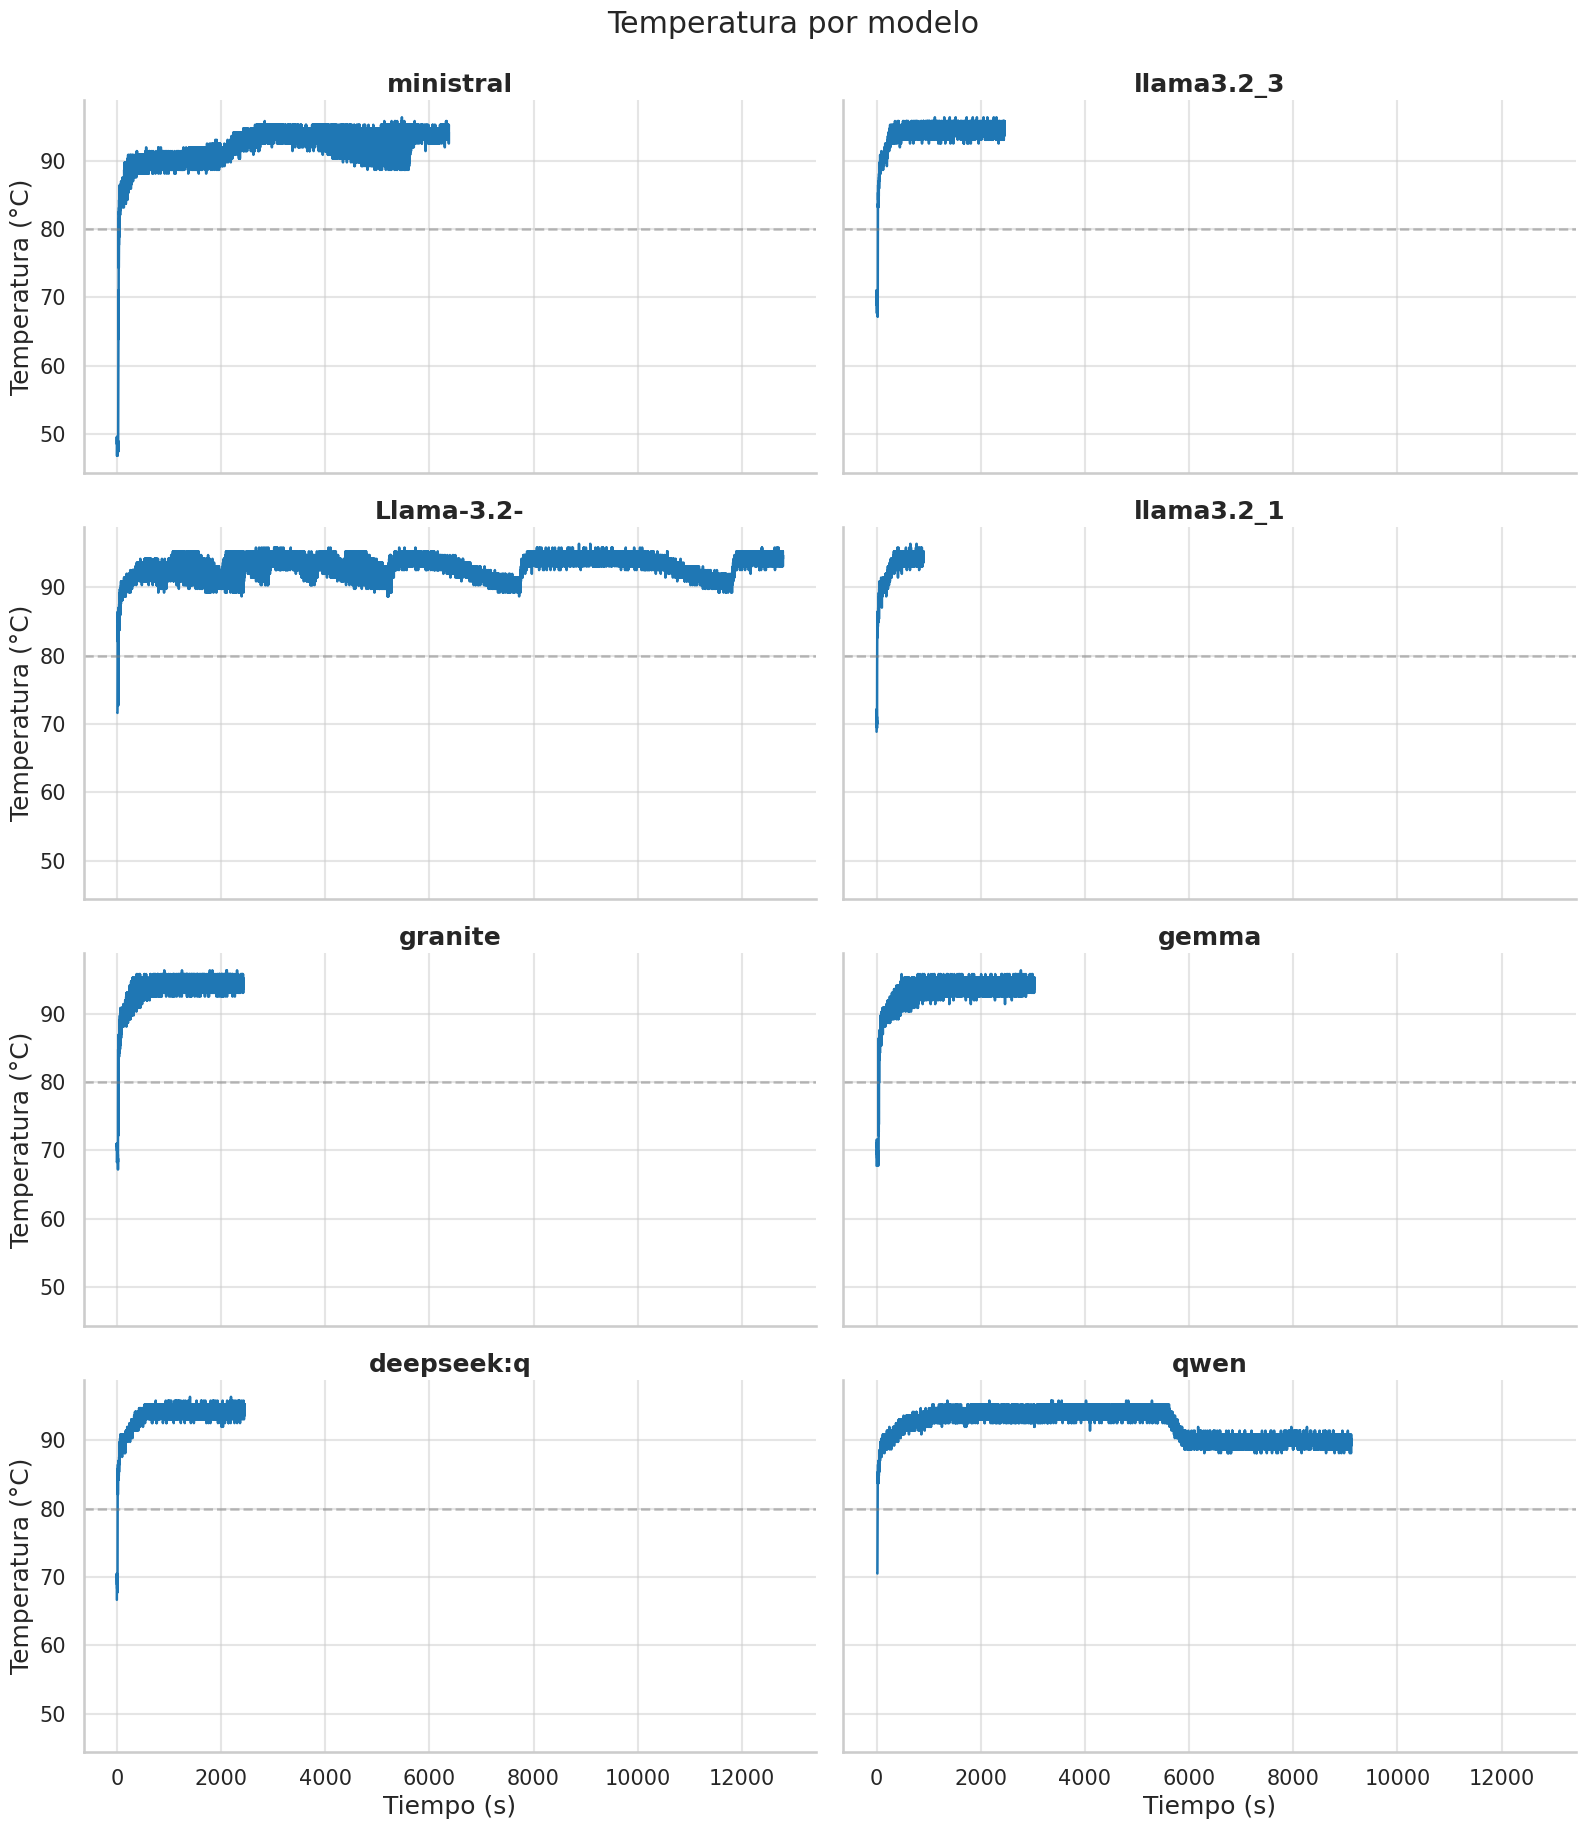

In [2]:
hw_df = hw_runs.hw_metrics_df()

g = sns.relplot(
    data=hw_df, kind="line",
    x="t_rel_s", y="temperature_c",
    col="model_label", col_wrap=2,
    height=4.5, aspect=1.8,
    facet_kws={"sharey": True},
)
g.set_xlabels("Tiempo (s)")
g.set_ylabels("Temperatura (°C)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.axhline(80, ls="--", color="gray", alpha=0.5, label="80 °C")
g.fig.suptitle("Temperatura por modelo", y=1.02)
plt.show()


## Potencia interna

El consumo de potencia correlaciona directamente con la carga computacional.
Modelos más grandes consumen más. La potencia base (idle, antes de que empiece
la inferencia) es ~3 W en la RPi5.

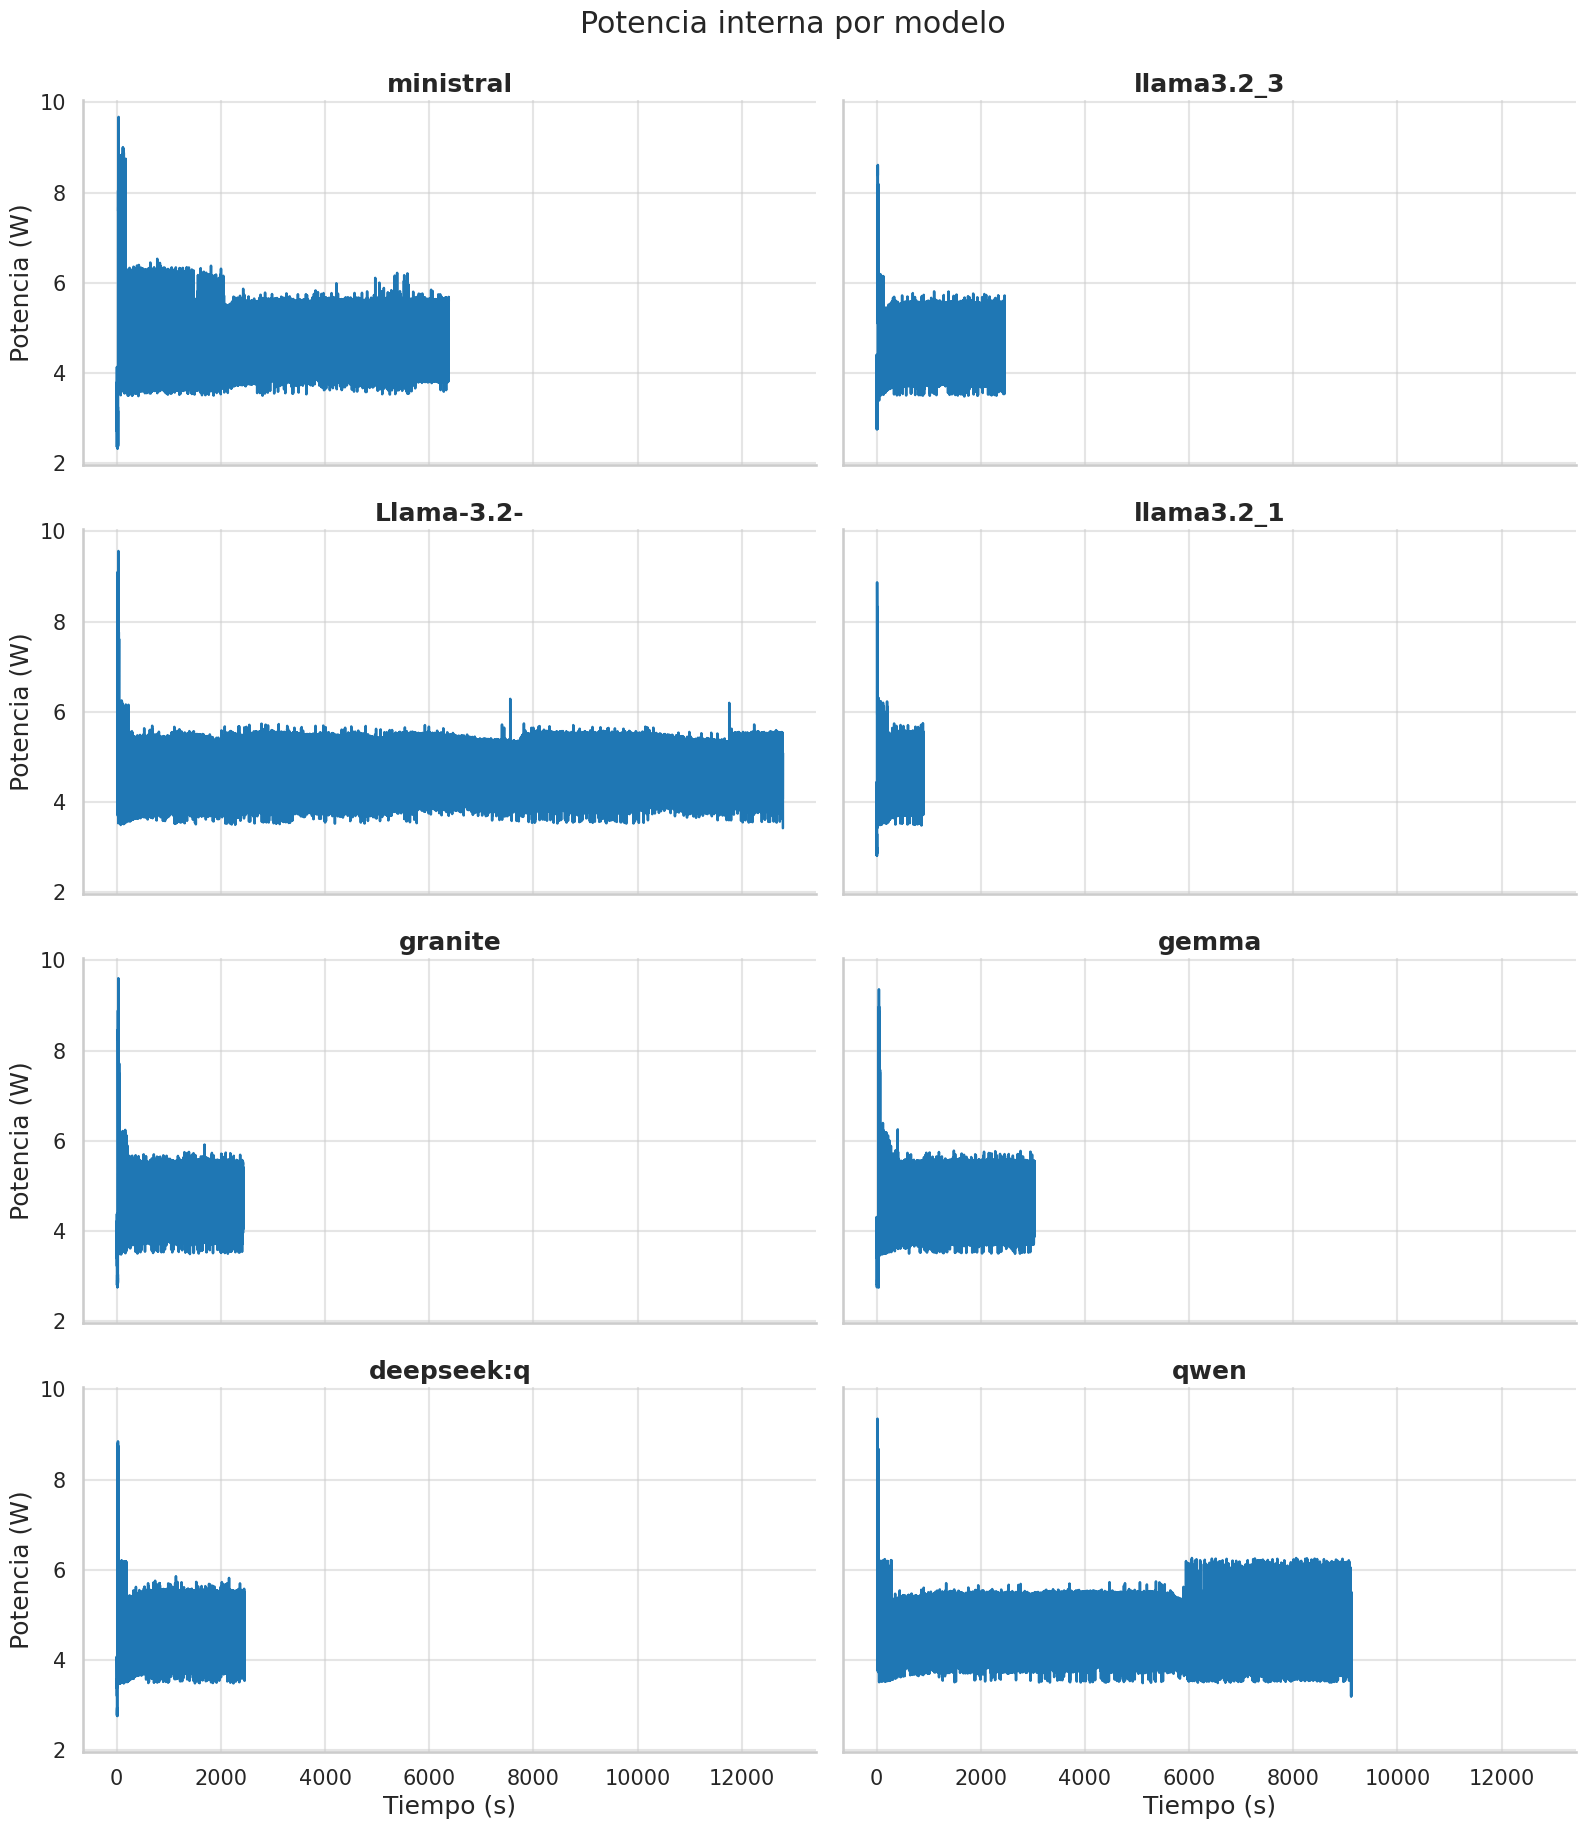

In [3]:
g = sns.relplot(
    data=hw_df, kind="line",
    x="t_rel_s", y="internal_power_w",
    col="model_label", col_wrap=2,
    height=4.5, aspect=1.8,
    facet_kws={"sharey": True},
)
g.set_xlabels("Tiempo (s)")
g.set_ylabels("Potencia (W)")
g.set_titles("{col_name}")
g.fig.suptitle("Potencia interna por modelo", y=1.02)
plt.show()


## CPU y memoria

El uso de CPU durante inferencia en CPU-only es típicamente ~100%.
La memoria interesa para ver si el modelo cabe en RAM o se produce
paginación a swap.

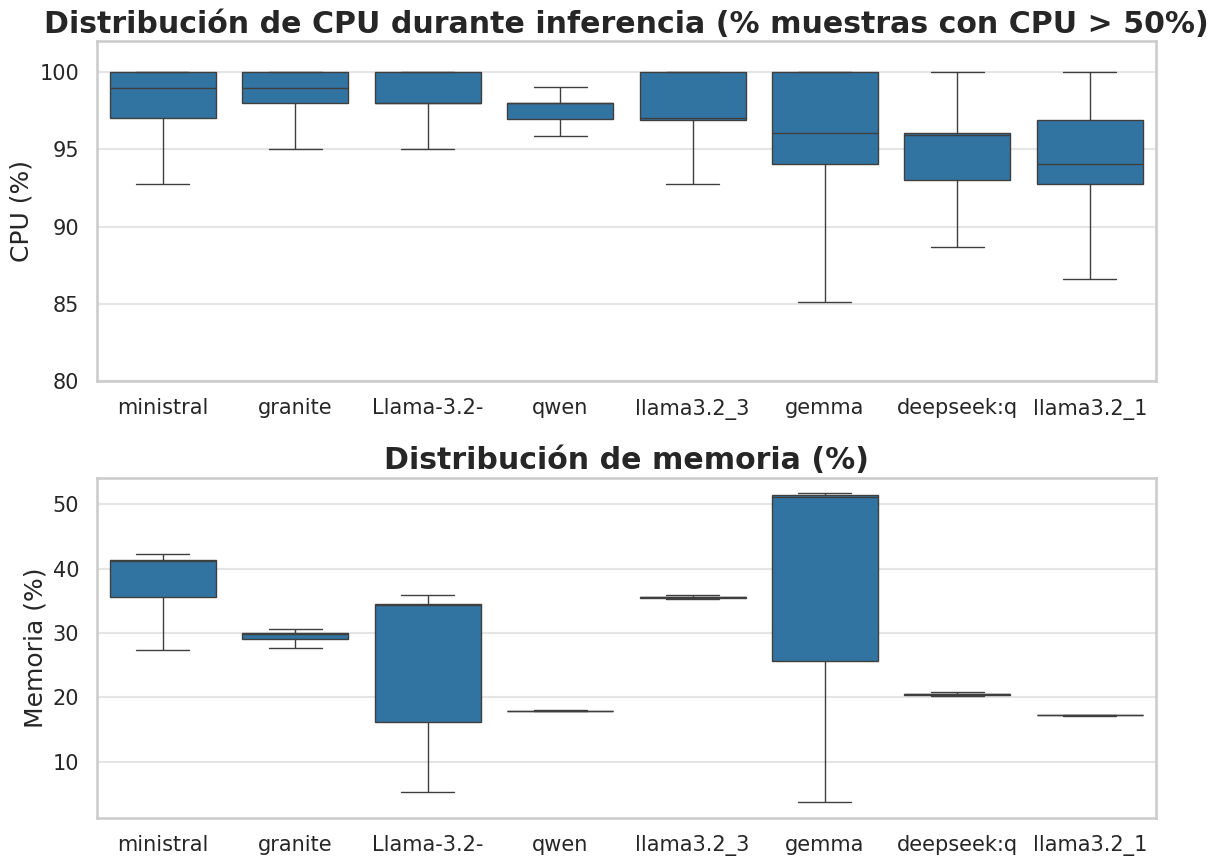

In [4]:
hw_inference = hw_df[hw_df["cpu_usage_pct"] > 50]

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

order = hw_df.groupby("model_label")["cpu_usage_pct"].median().sort_values(ascending=False).index

sns.boxplot(
    data=hw_inference, x="model_label", y="cpu_usage_pct",
    order=order, showfliers=False, ax=axes[0],
)
axes[0].set_title("Distribución de CPU durante inferencia (% muestras con CPU > 50%)")
axes[0].set_xlabel("")
axes[0].set_ylabel("CPU (%)")
axes[0].set_ylim(80, 102)

sns.boxplot(
    data=hw_df, x="model_label", y="mem_pct",
    order=order, showfliers=False, ax=axes[1],
)
axes[1].set_title("Distribución de memoria (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Memoria (%)")

fig.tight_layout()
plt.show()


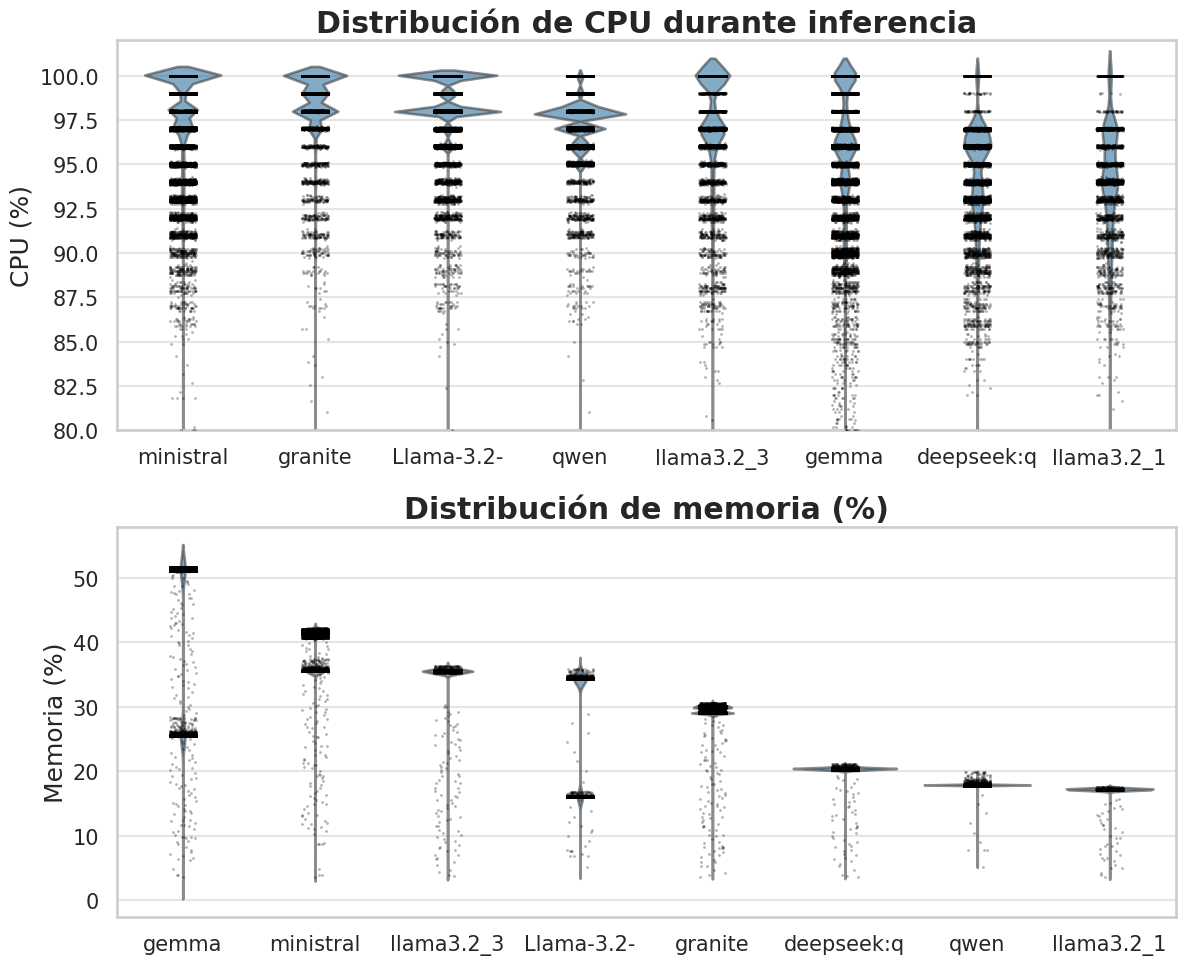

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

order = (hw_df.groupby("model_label")["cpu_usage_pct"]
         .median().sort_values(ascending=False).index.tolist())

# CPU — violin + strip
active = hw_df[hw_df["cpu_usage_pct"] > 50]
sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
               order=order, inner=None, alpha=0.6, ax=axes[0])
sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
              order=order, size=2, alpha=0.3, color="black", ax=axes[0])
axes[0].set_title("Distribución de CPU durante inferencia")
axes[0].set_xlabel("")
axes[0].set_ylabel("CPU (%)")
axes[0].set_ylim(80, 102)

# Memoria — violin + strip (todas las muestras, no solo activas)
mem_order = (hw_df.groupby("model_label")["mem_pct"]
             .median().sort_values(ascending=False).index.tolist())
sns.violinplot(data=hw_df, x="model_label", y="mem_pct",
               order=mem_order, inner=None, alpha=0.6, ax=axes[1])
sns.stripplot(data=hw_df, x="model_label", y="mem_pct",
              order=mem_order, size=2, alpha=0.3, color="black", ax=axes[1])
axes[1].set_title("Distribución de memoria (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Memoria (%)")

fig.tight_layout()
plt.show()

## Throttling

Porcentaje de muestras con throttling activo por modelo. Un valor > 0
indica que el hardware está limitando el rendimiento por protección térmica.

In [6]:
throttle_summary = (
    hw_df.groupby("model_short")["throt_any_active"]
    .agg(["sum", "count"])
    .assign(ratio_pct=lambda d: d["sum"] / d["count"] * 100)
    .rename(columns={"sum": "muestras_throttled", "count": "total_muestras"})
    .round(2)
)
throttle_summary

,muestras_throttled,total_muestras,ratio_pct
model_short,,,
DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M,36345,36363,99.95
Llama-3.2-1B-Instruct-Q4_K_M,20977,20992,99.93
Llama-3.2-3B-Instruct-Q4_K_M,50988,51009,99.96
Ministral-3-3B-Instruct-2512-Q4_K_M,22765,22815,99.78
deepseek:q4_k_m,9748,9810,99.37
gemma-4.5B-3n-E2B-it-Q4_K_M,11146,11167,99.81
gemma:q4_k_m,11960,12128,98.61
granite-4.0-h-micro-Q4_K_M,8565,8585,99.77
granite:q4_k_m,9603,9700,99.00


## Swap bajo carga

Si algún modelo fuerza el uso de swap, se notará aquí como un aumento
sostenido durante la inferencia.

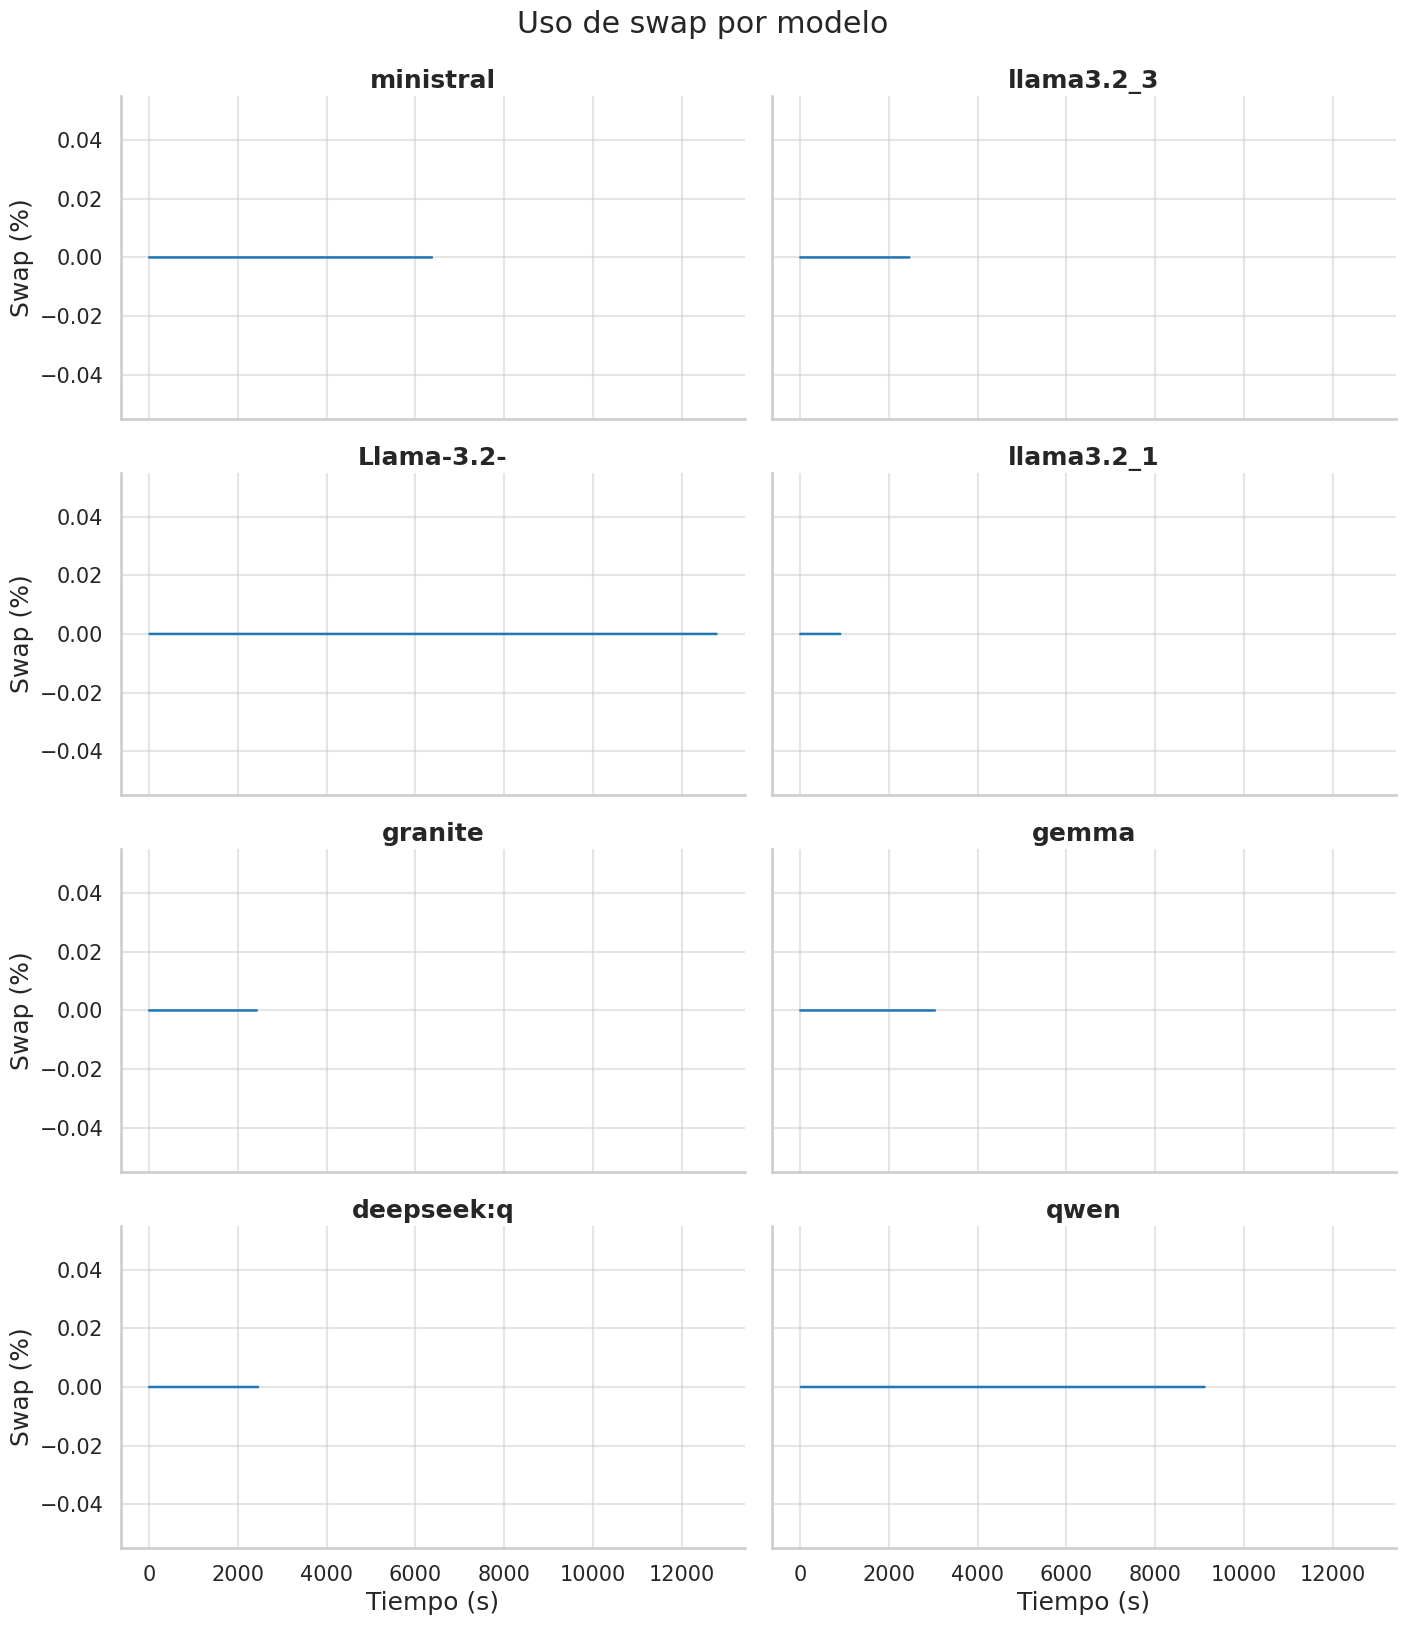

In [7]:
g = sns.relplot(
    data=hw_df, kind="line",
    x="t_rel_s", y="swap_pct",
    col="model_label", col_wrap=2,
    height=4, aspect=1.8,
    facet_kws={"sharey": True},
)
g.set_xlabels("Tiempo (s)")
g.set_ylabels("Swap (%)")
g.set_titles("{col_name}")
g.fig.suptitle("Uso de swap por modelo", y=1.02)
plt.show()


## Temperatura y frecuencia (Benoit-Cattin et al., 2020)

La siguiente visualización reproduce el esquema de análisis térmico de
Benoit-Cattin et al. (2020): temperatura CPU (eje izquierdo) y frecuencia
media (eje derecho) a lo largo del tiempo. El throttling térmico se
manifiesta como una reducción de frecuencia cuando la temperatura supera
los 80 °C.

Además se muestra la variante B de la Fig. 2.16 del TFG (RAM + CPU con
líneas verticales de fase) y el panel de histogramas de métricas hw.

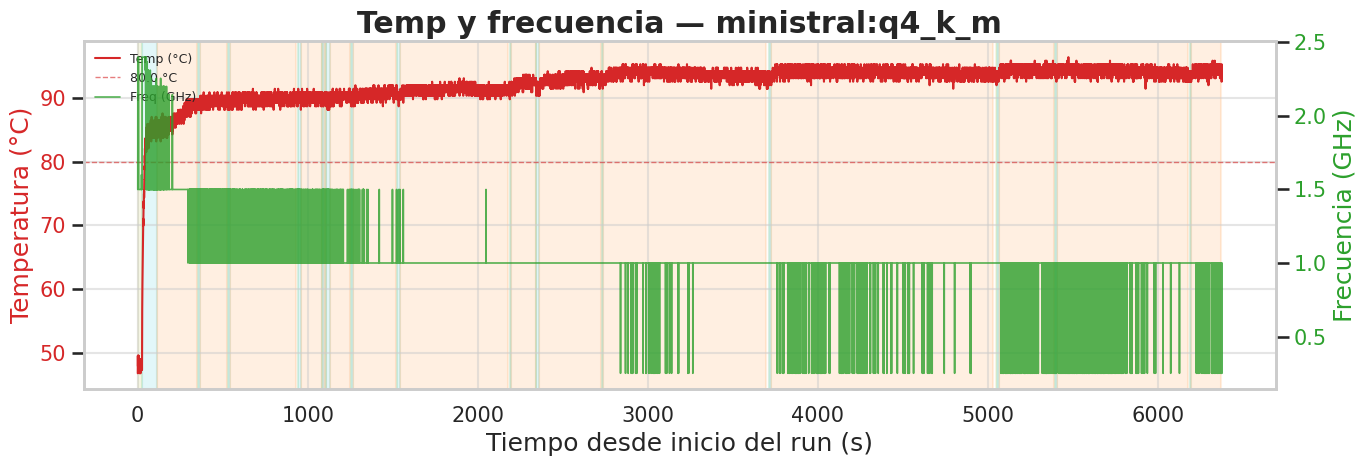

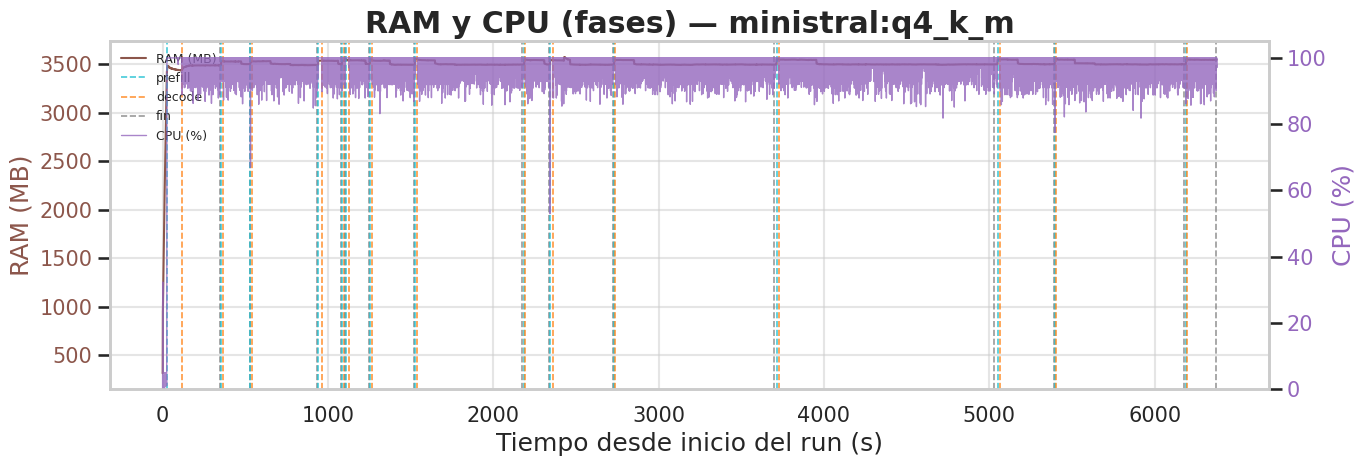

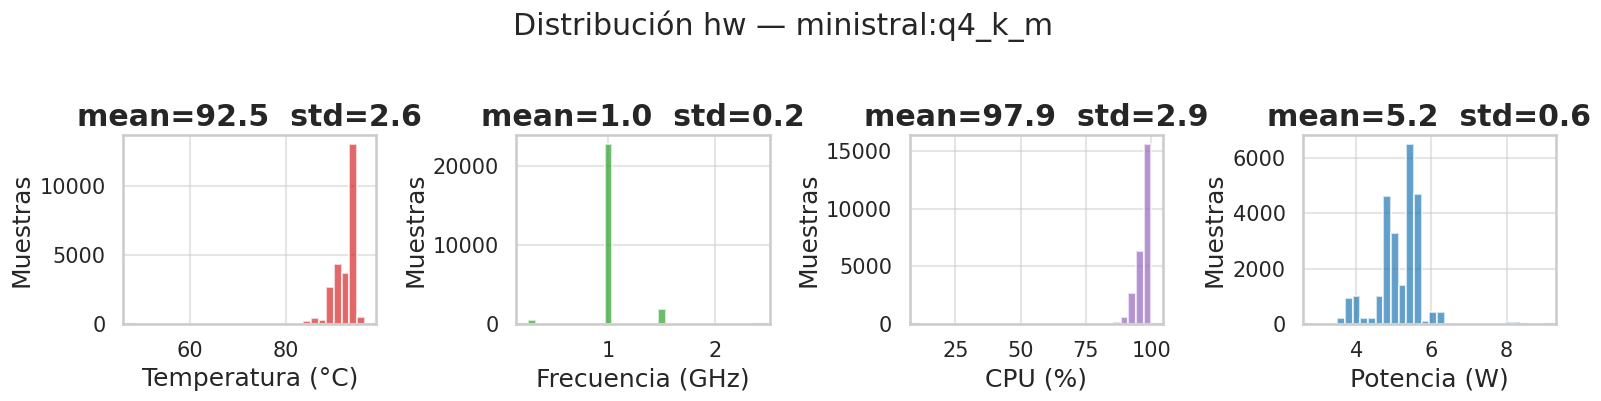

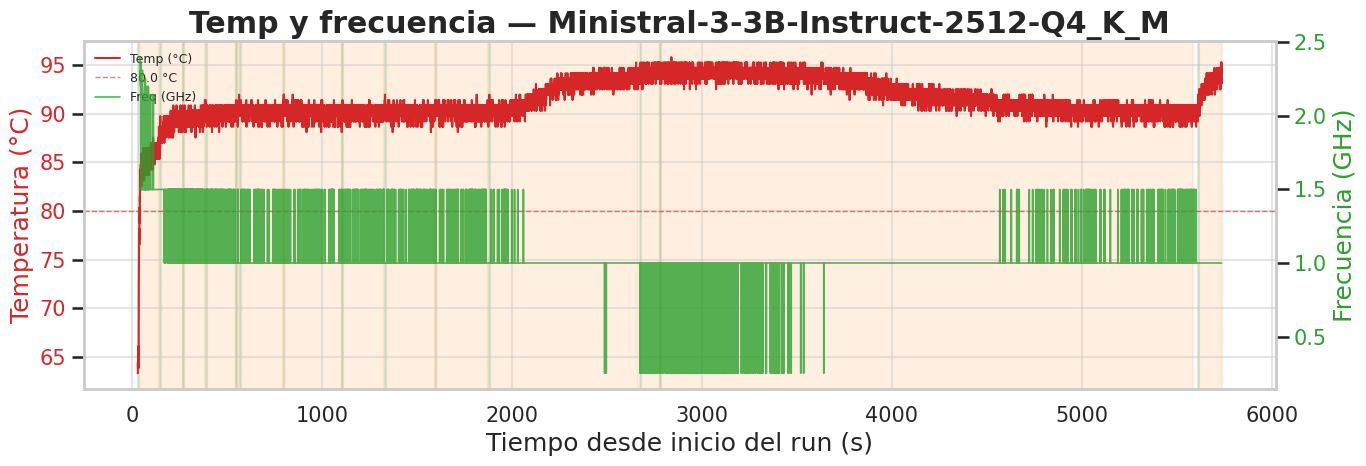

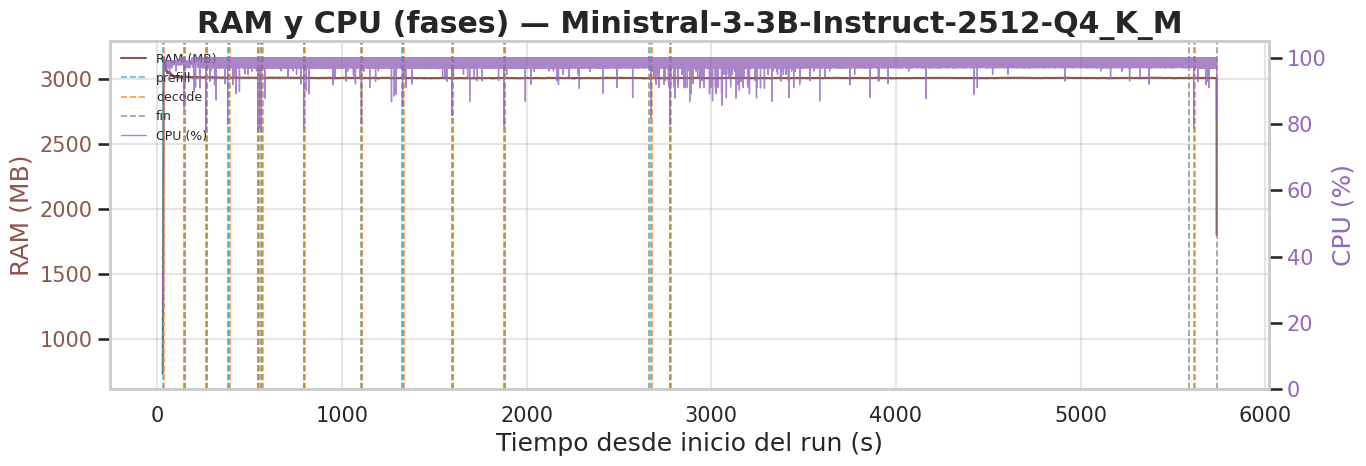

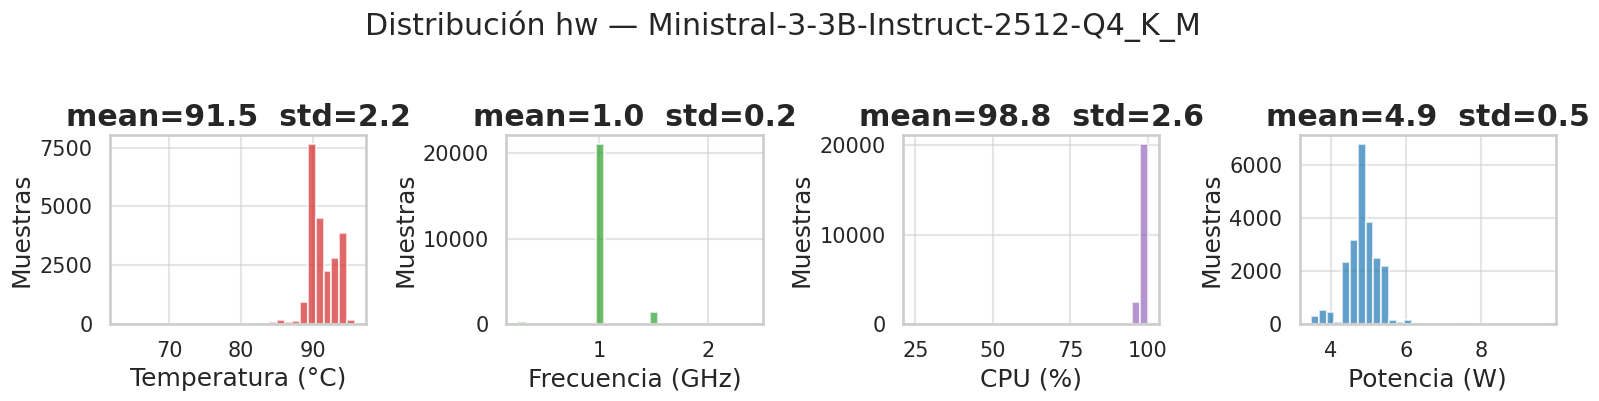

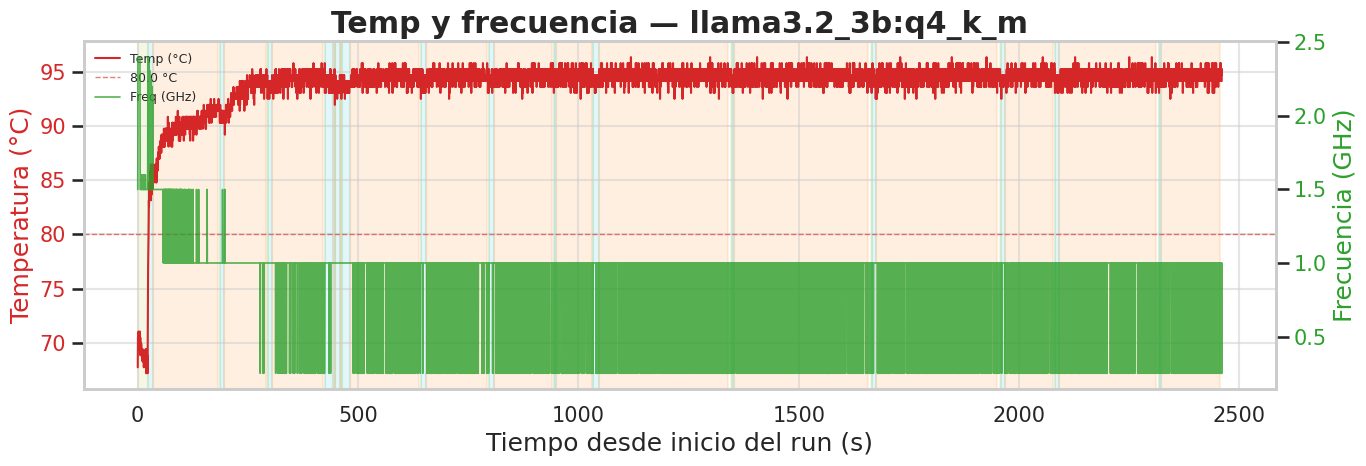

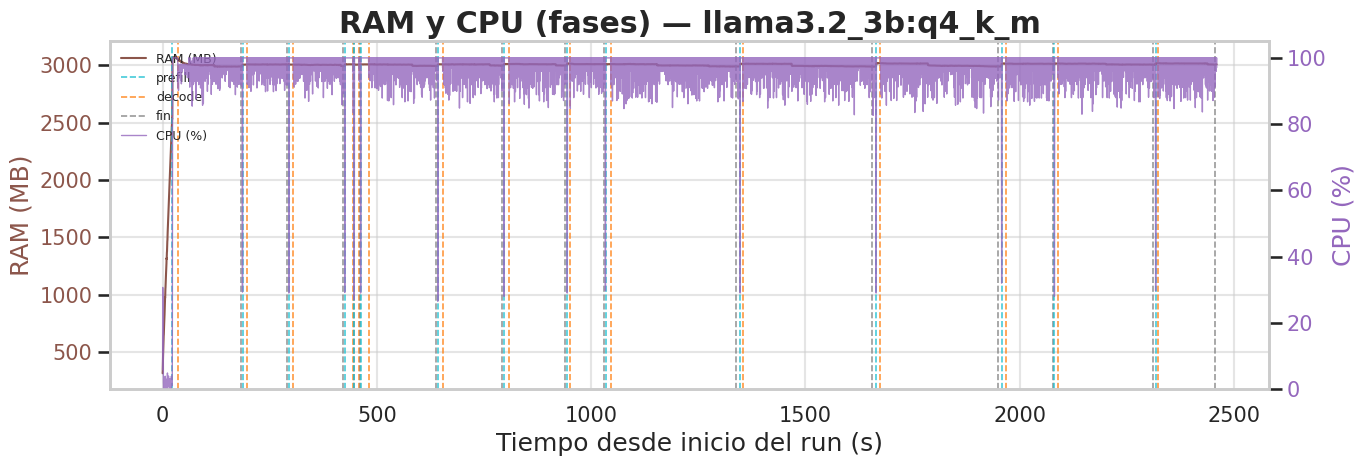

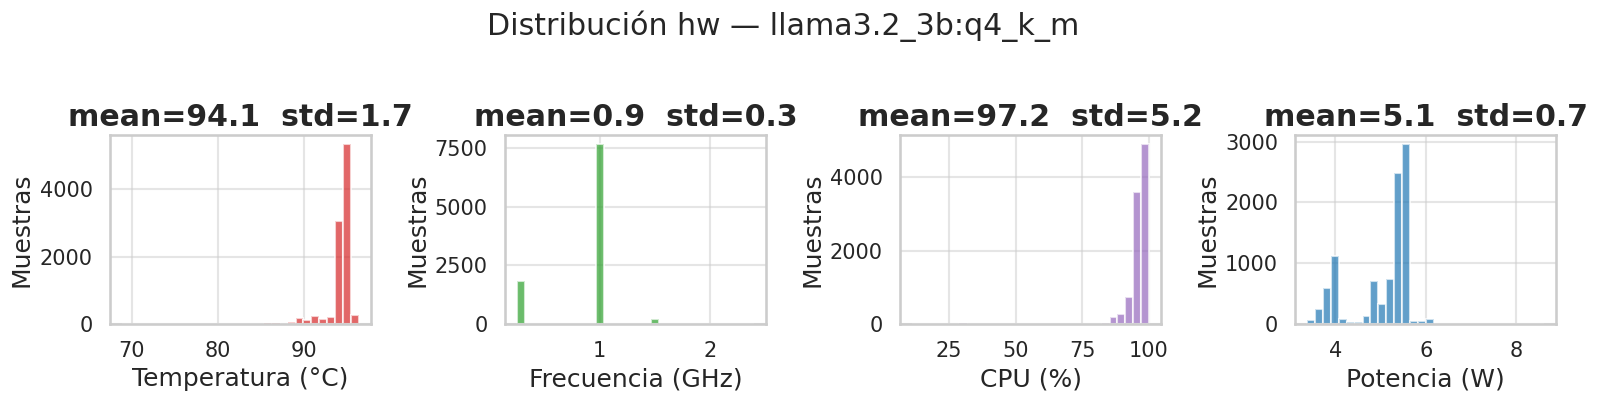

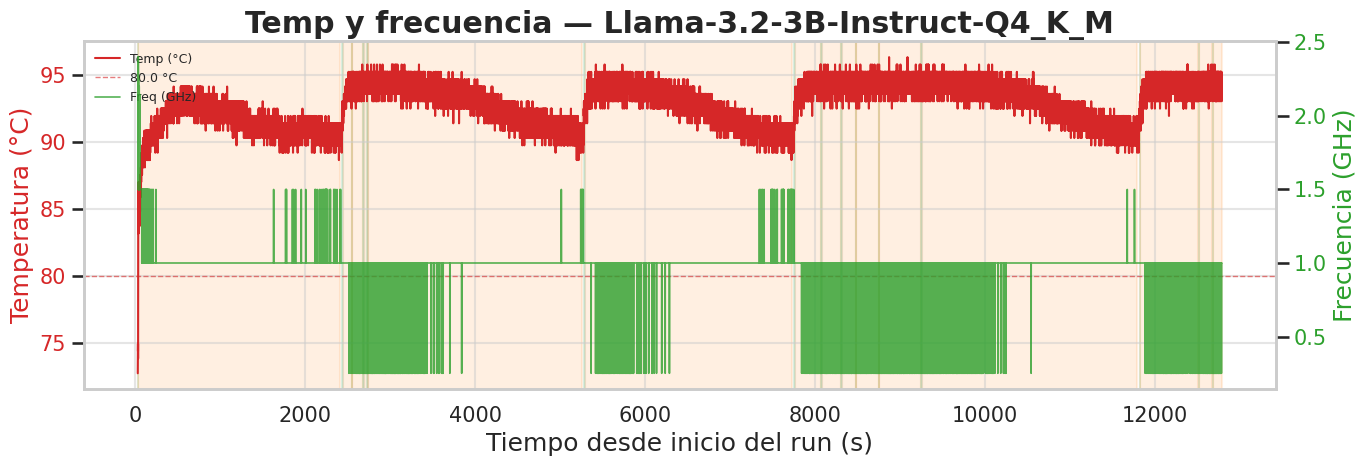

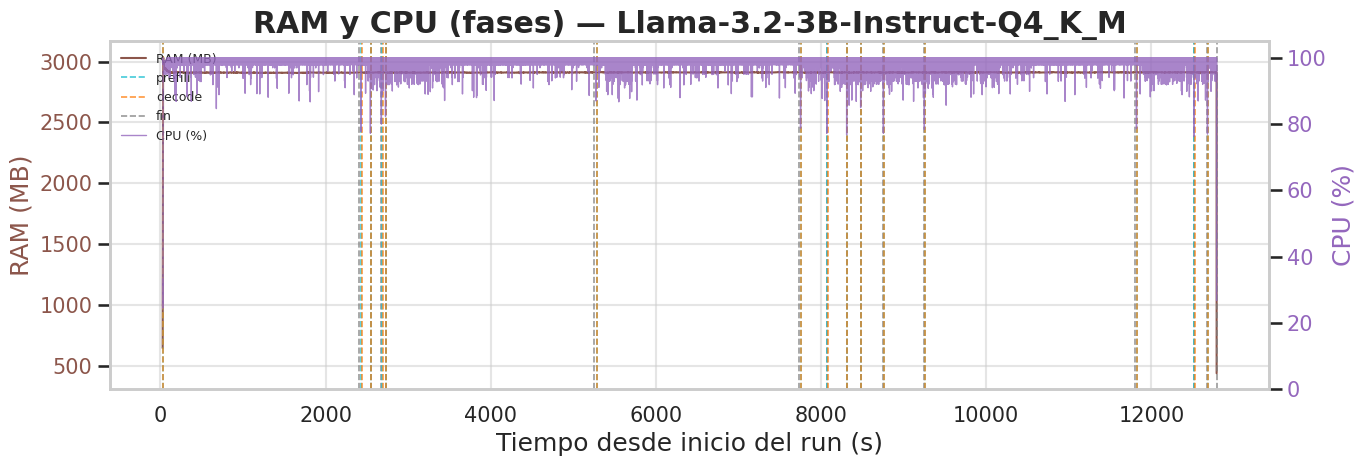

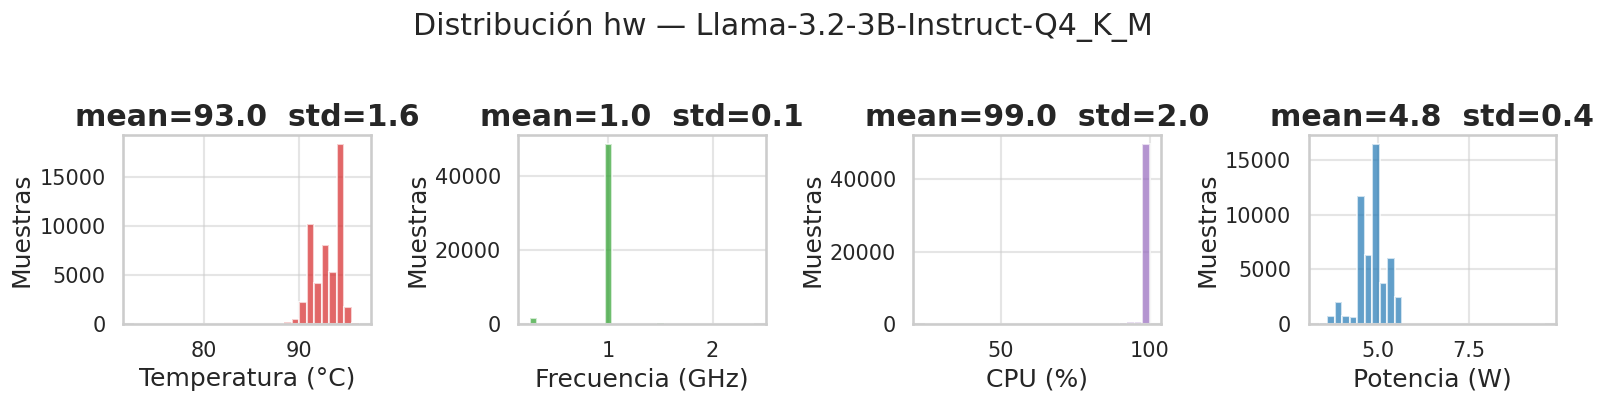

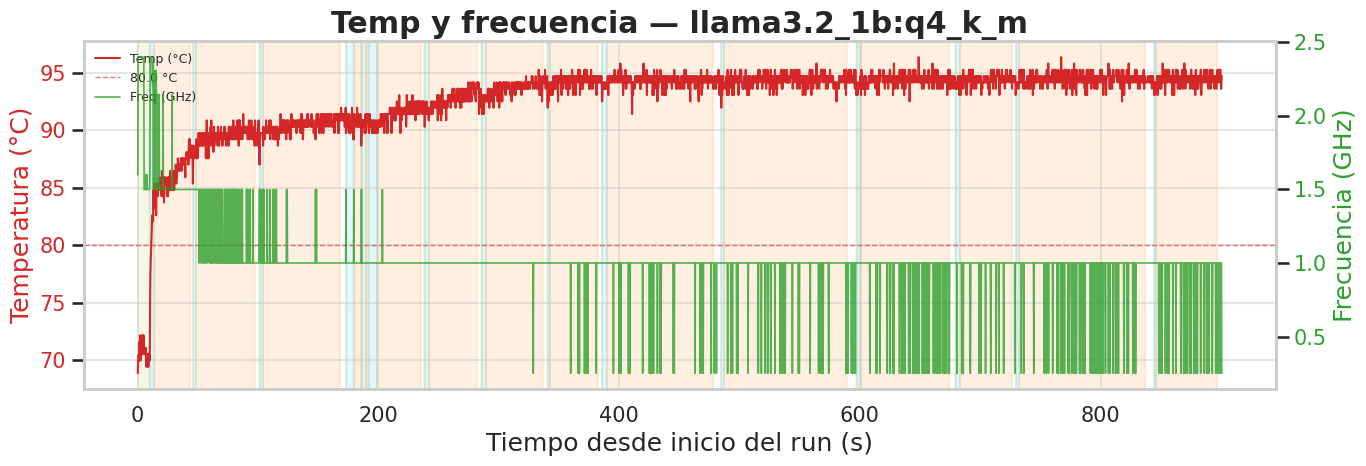

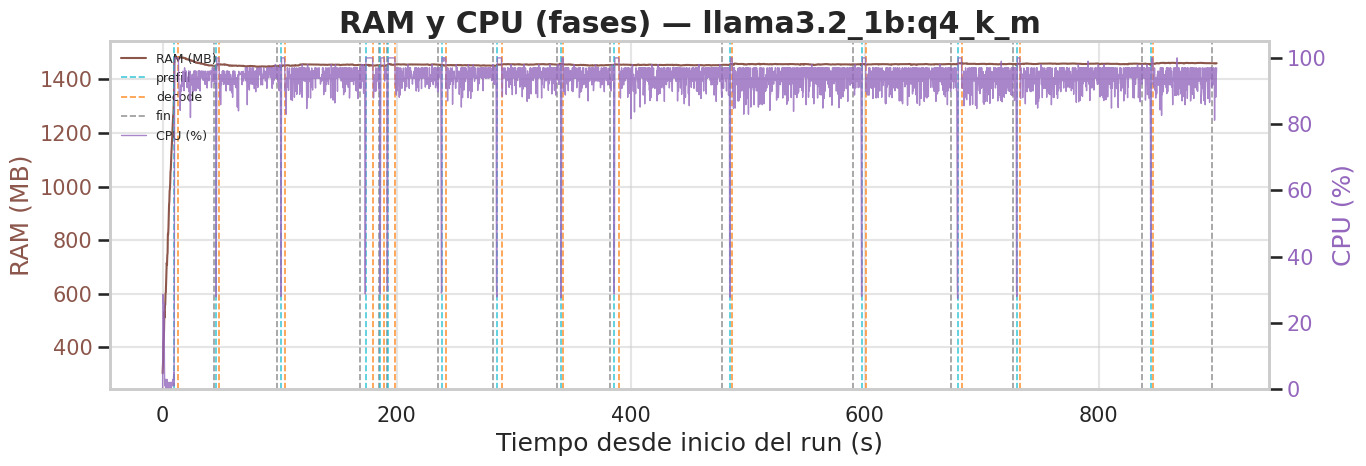

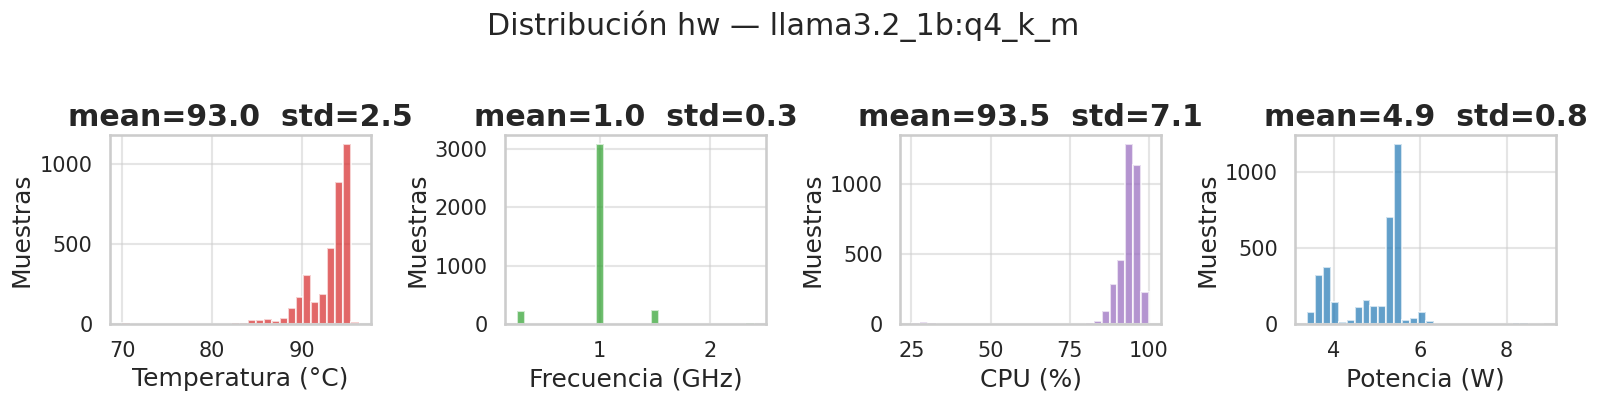

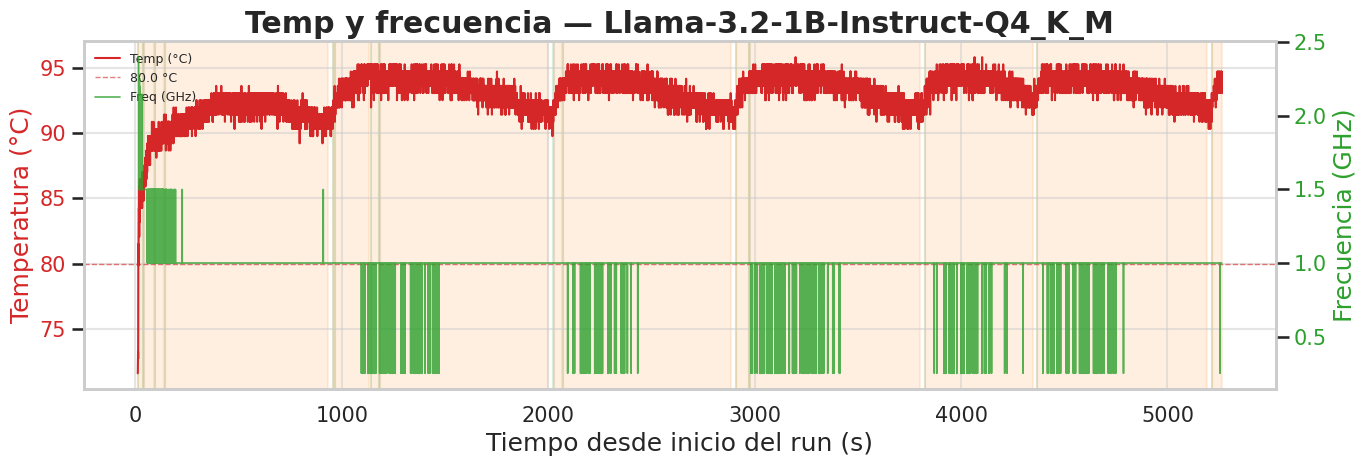

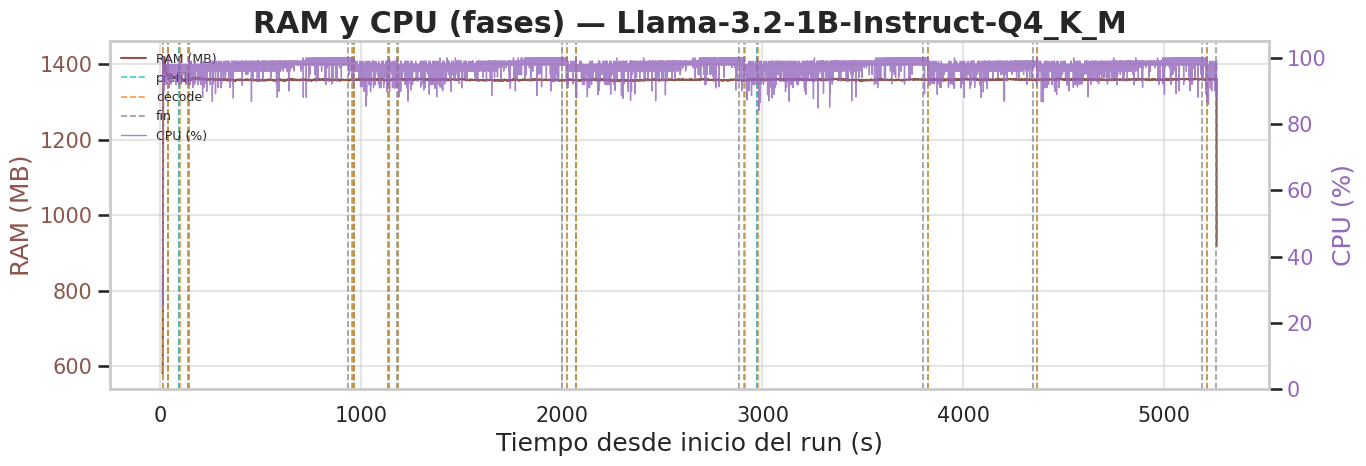

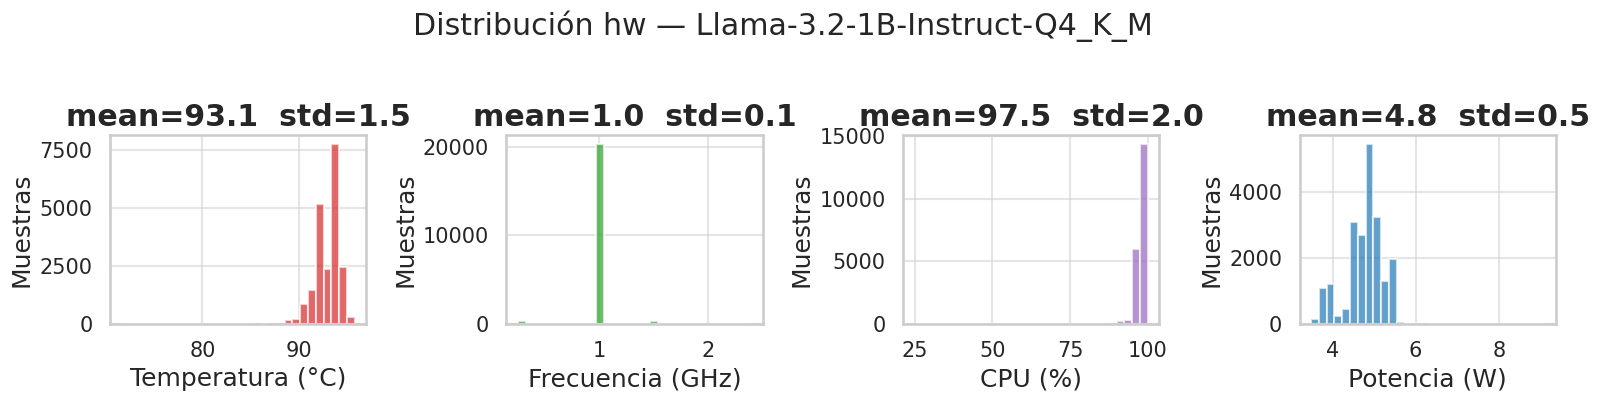

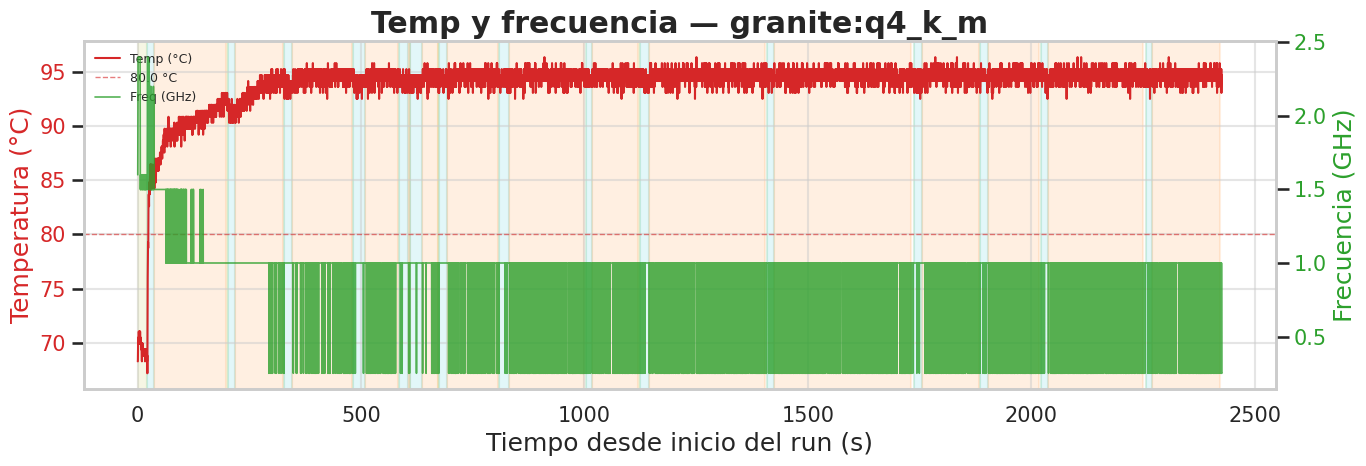

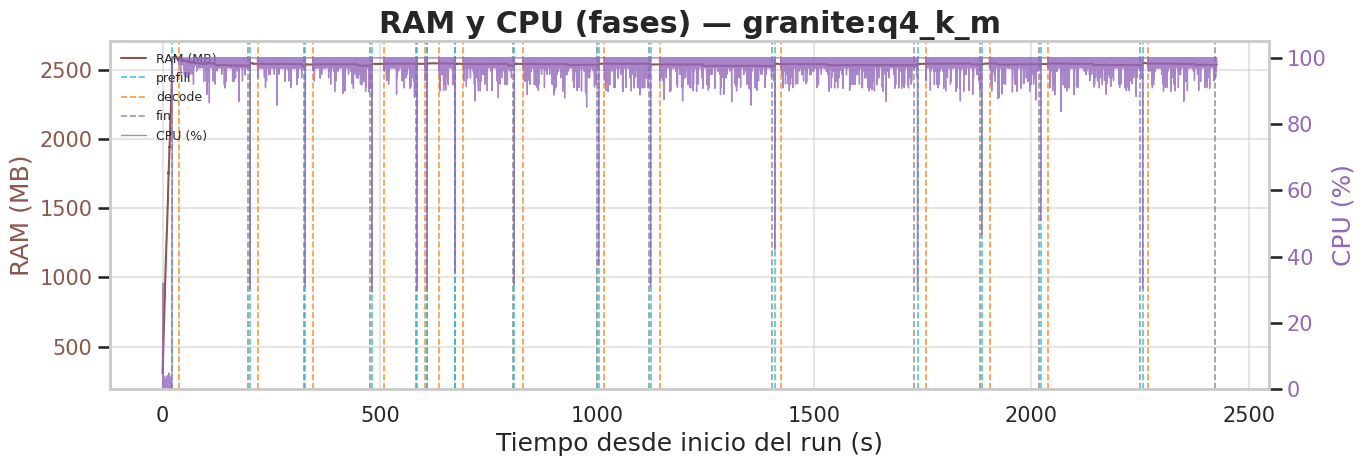

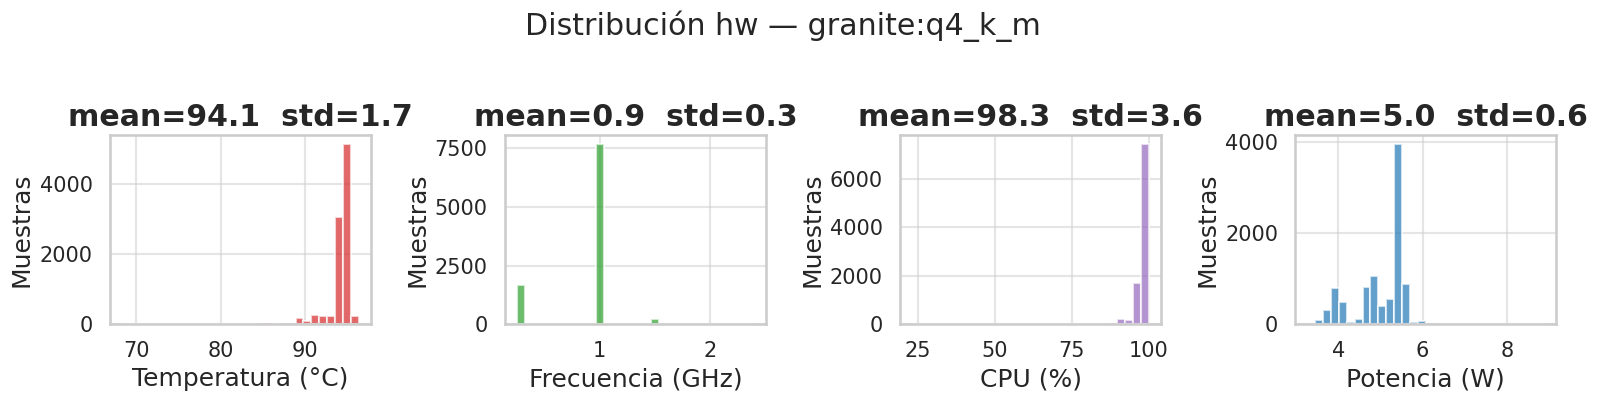

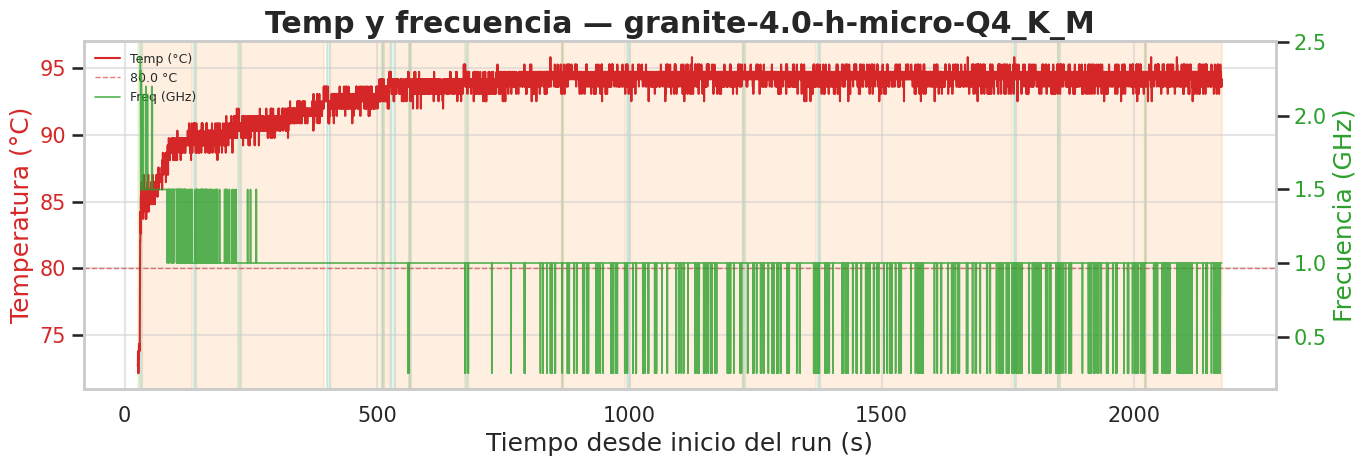

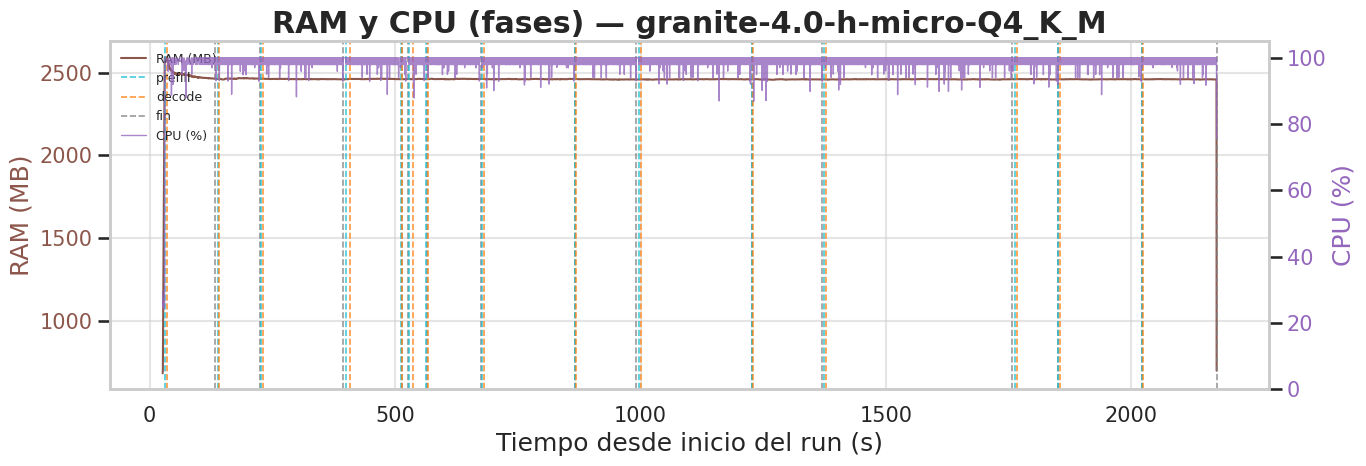

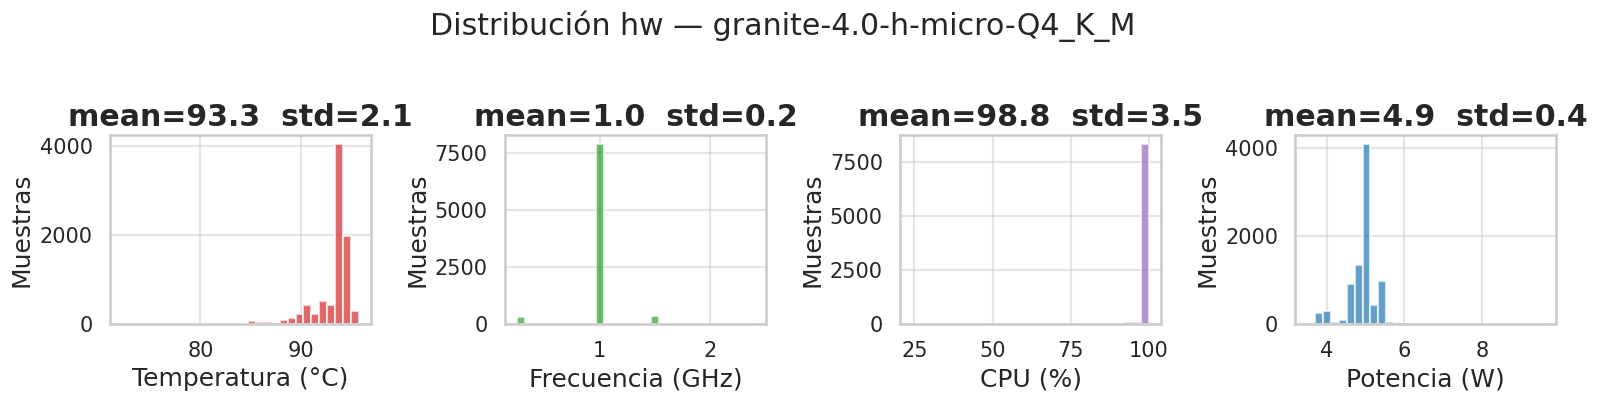

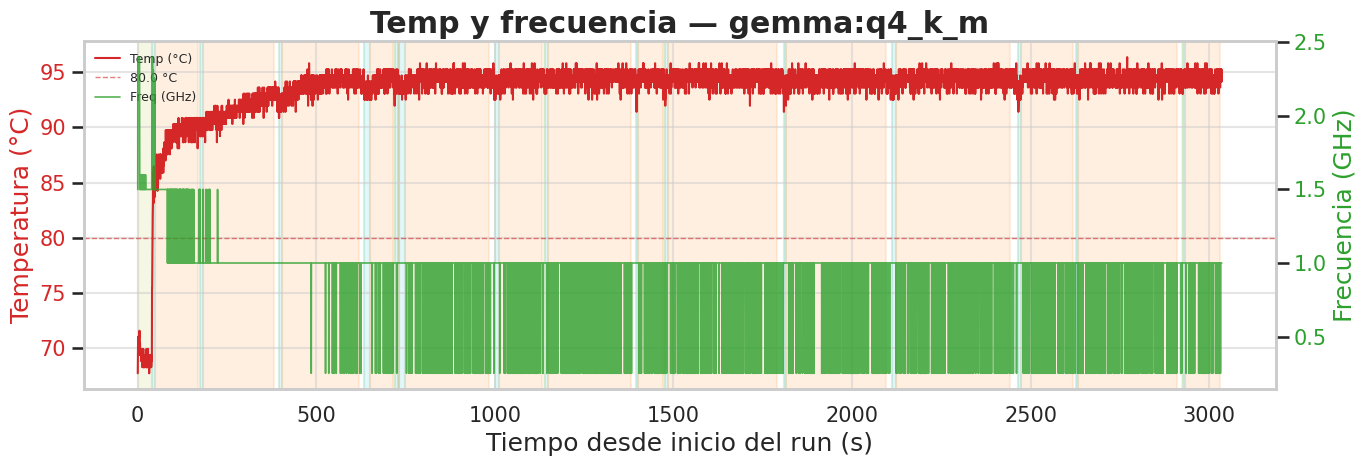

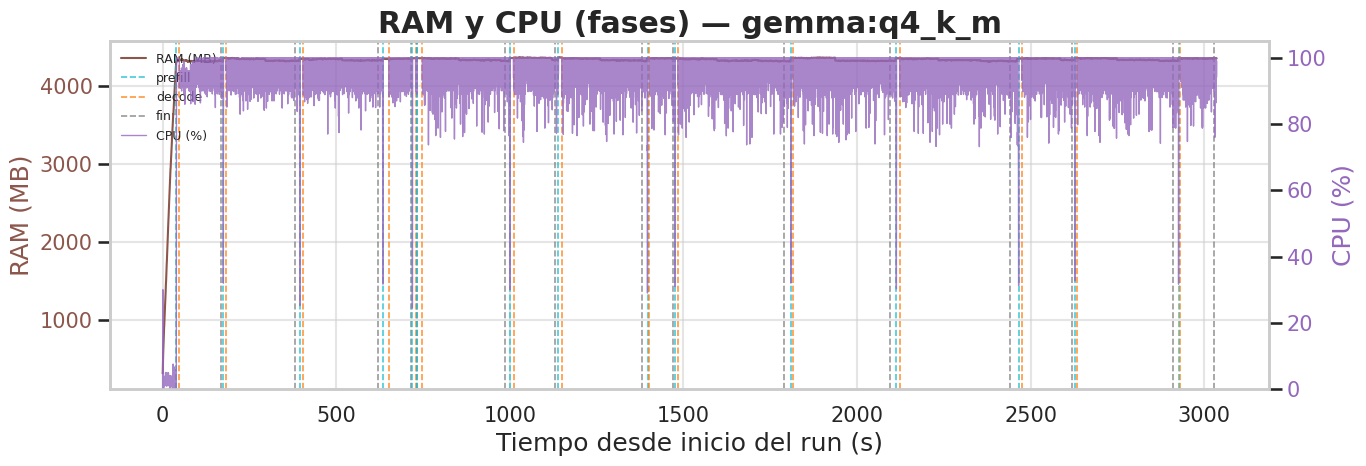

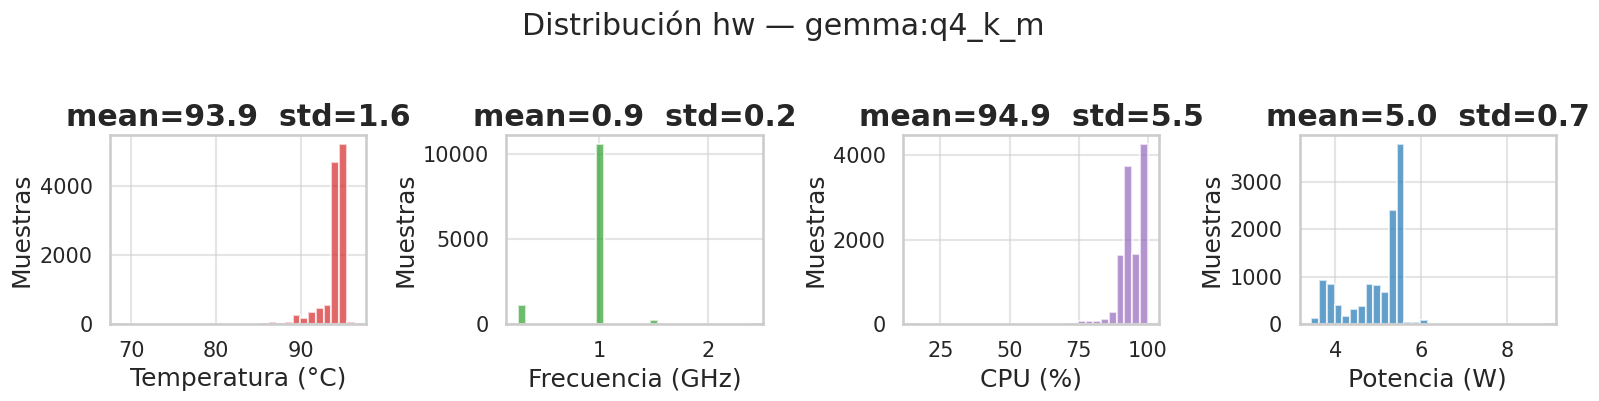

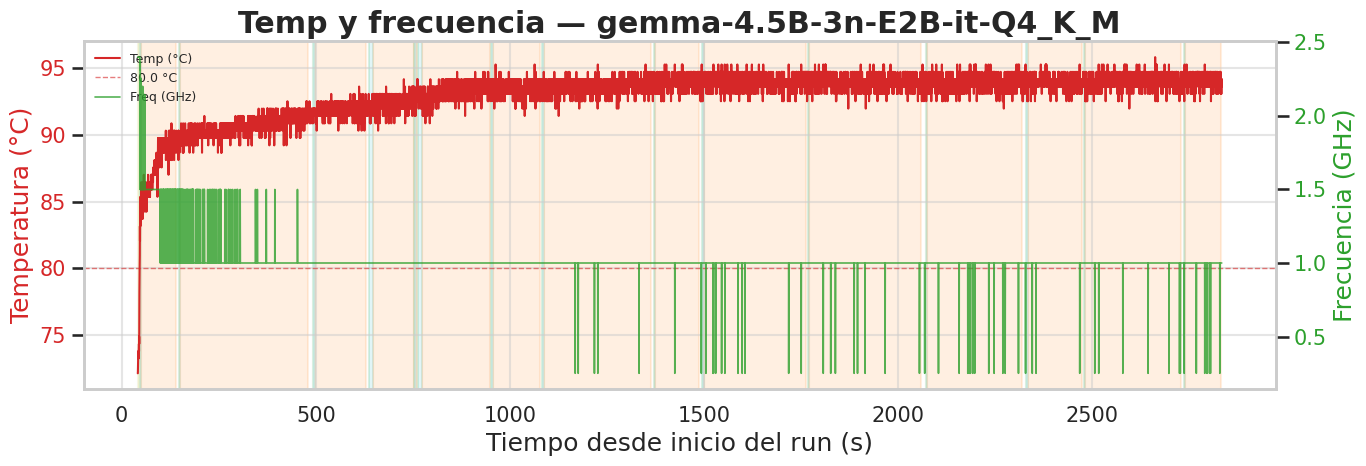

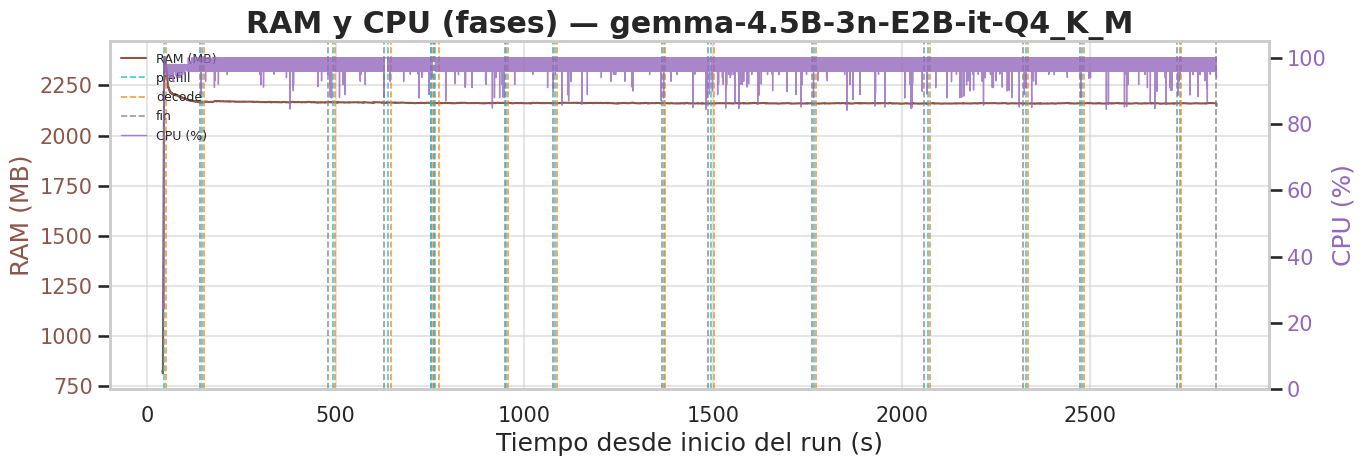

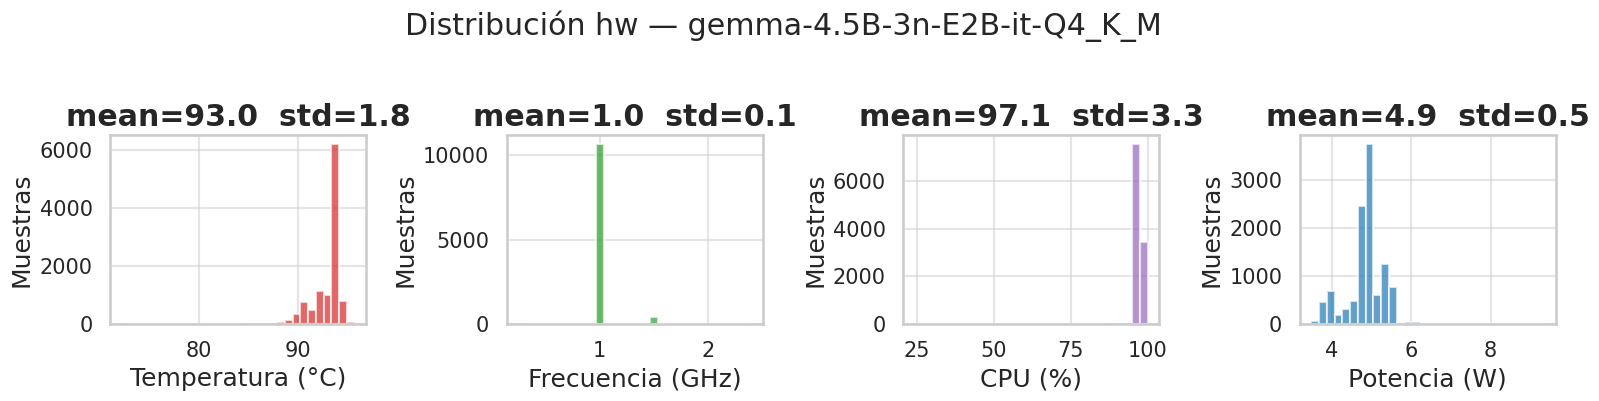

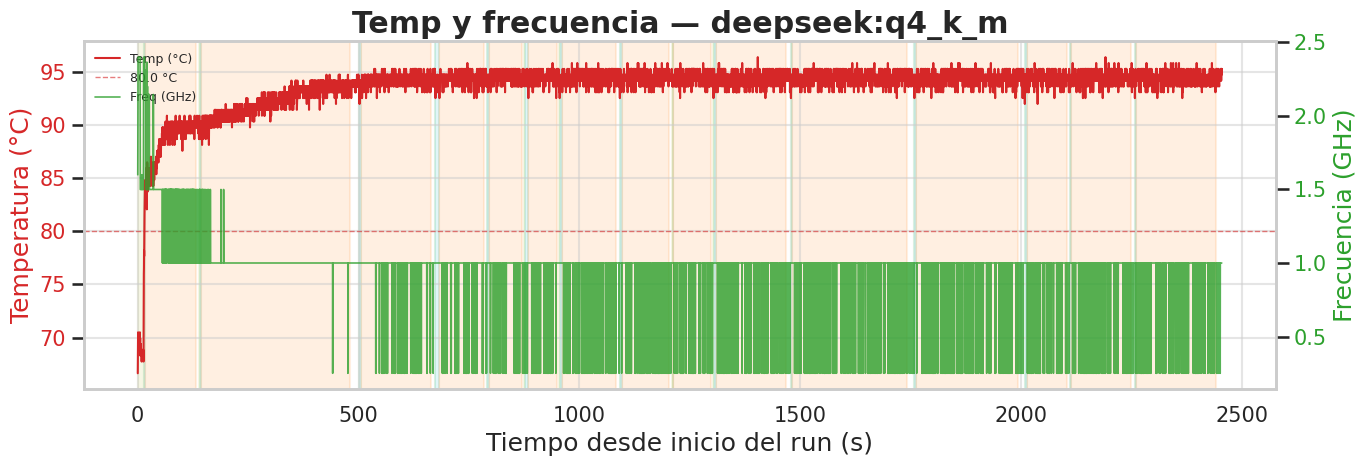

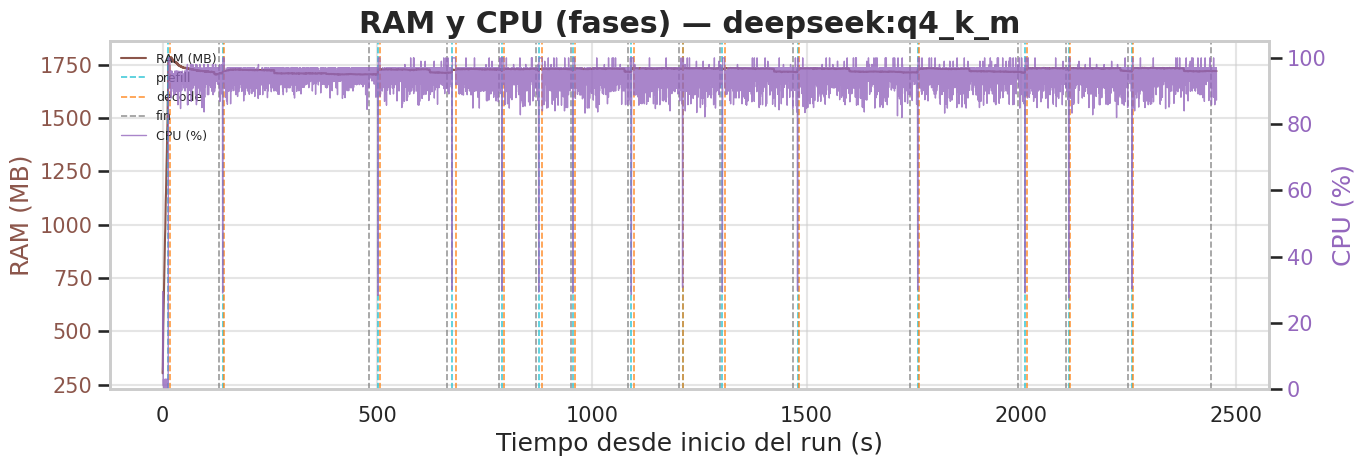

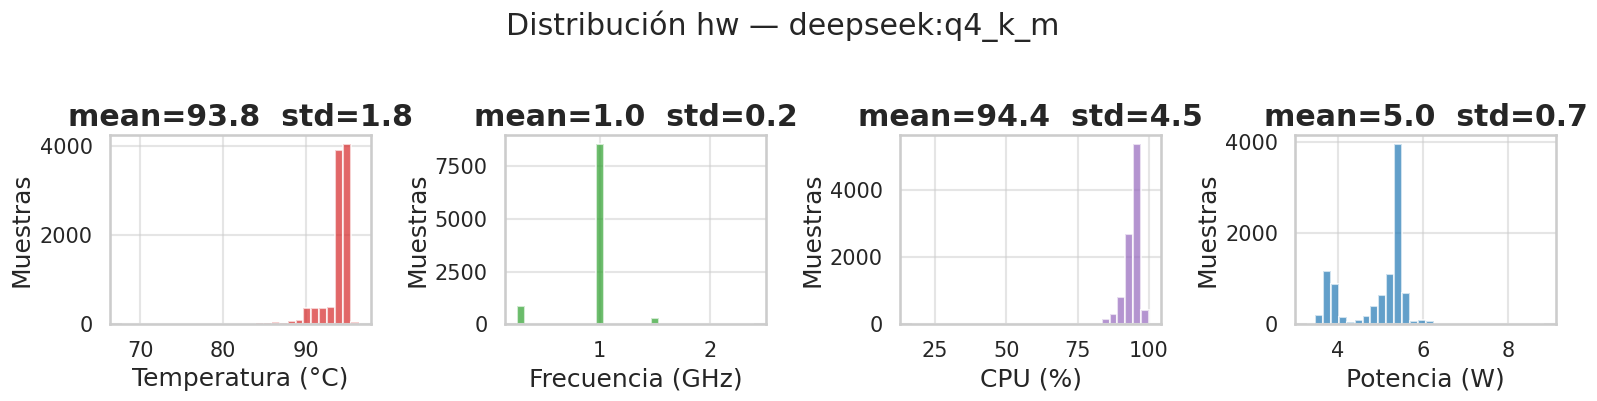

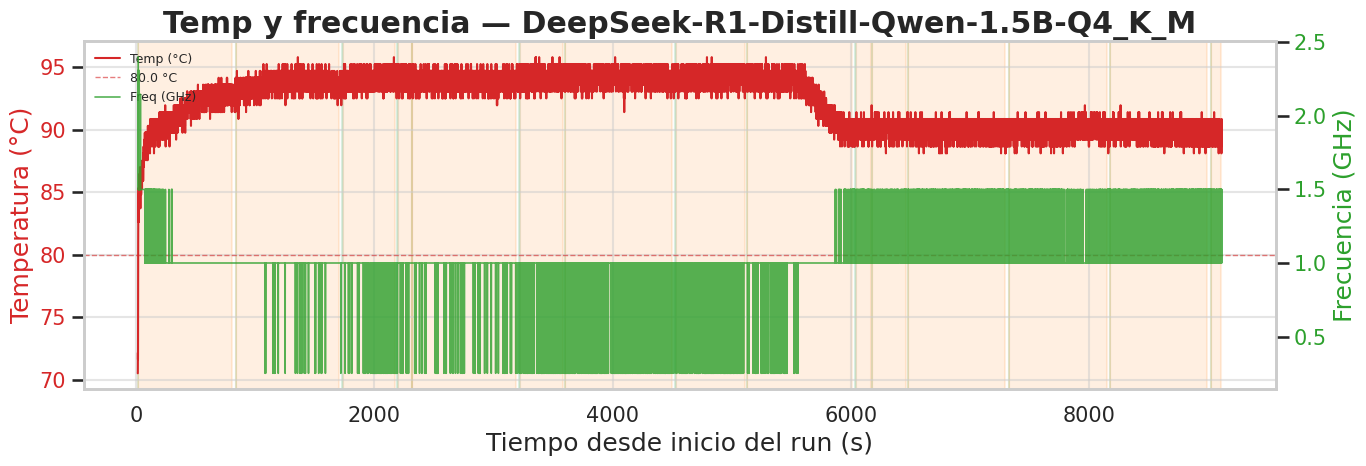

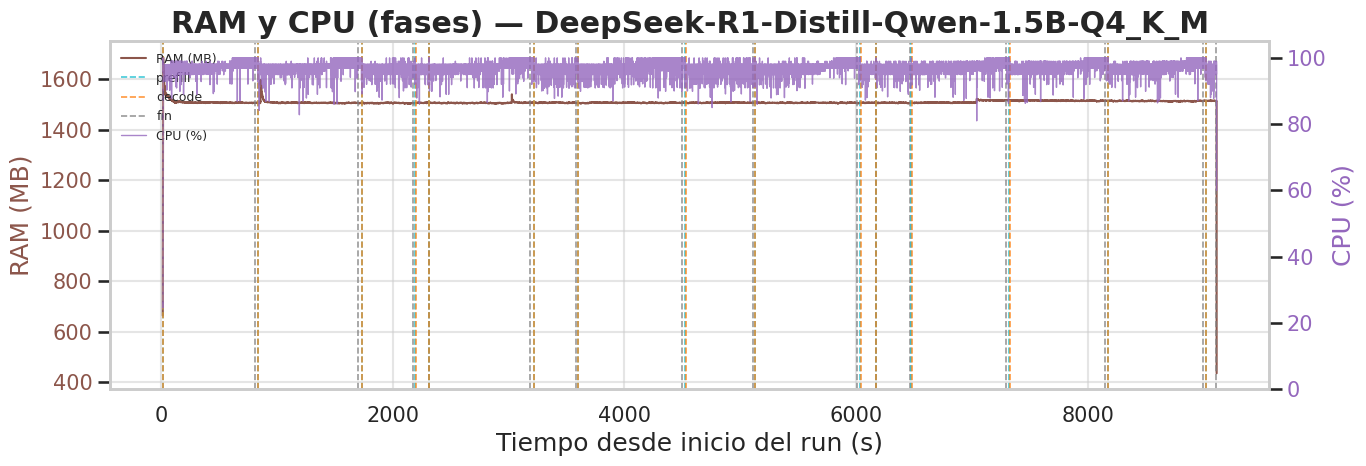

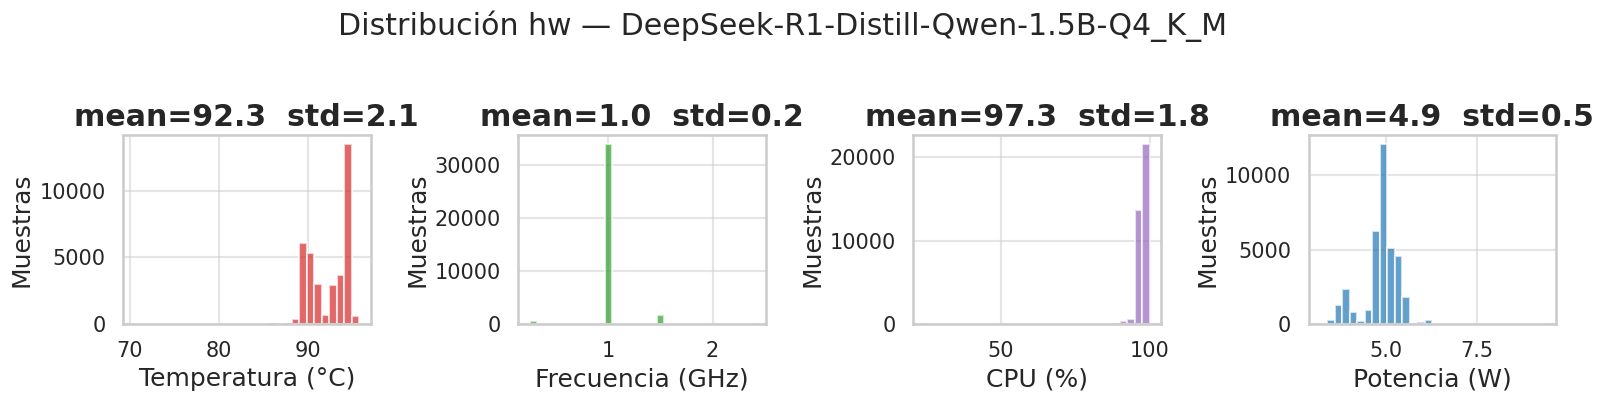

In [8]:
from monitorviz.transforms import hw_metrics_to_df
from monitorviz.viz import cpu_memory_dual_phases, hw_distributions_panel, temp_freq_dual

for r in hw_runs.runs:
    hw = hw_runs.hw_metrics_df()
    hw_r = hw[hw["run_id"] == r.run_id]
    if hw_r.empty:
        continue

    # Temp + freq dual Y (Benoit-Cattin panel i)
    fig = temp_freq_dual(hw_r, r, title=f"Temp y frecuencia — {r.model_short}")
    plt.show()

    # RAM + CPU con líneas de fase (Fig. 2.16 variante B)
    fig = cpu_memory_dual_phases(hw_r, r, title=f"RAM y CPU (fases) — {r.model_short}")
    plt.show()

    # Histogramas hw (Benoit-Cattin panel iii)
    fig = hw_distributions_panel(hw_r, r, title=f"Distribución hw — {r.model_short}")
    plt.show()

## Comparativa de métricas hardware por modelo

Barplot agrupado de cuatro métricas hardware clave, agrupadas por modelo
y coloreadas por configuración (ventilador activo / sin ventilador).
Inspirado en Velasco-Montero et al. (2022), Cap. 4, Fig. 4.5.

Cuando estén disponibles runs con fan=False (Experimento E0), aparecerá
la barra comparativa. Con los datos actuales (fan=True) se muestra una
barra por modelo.

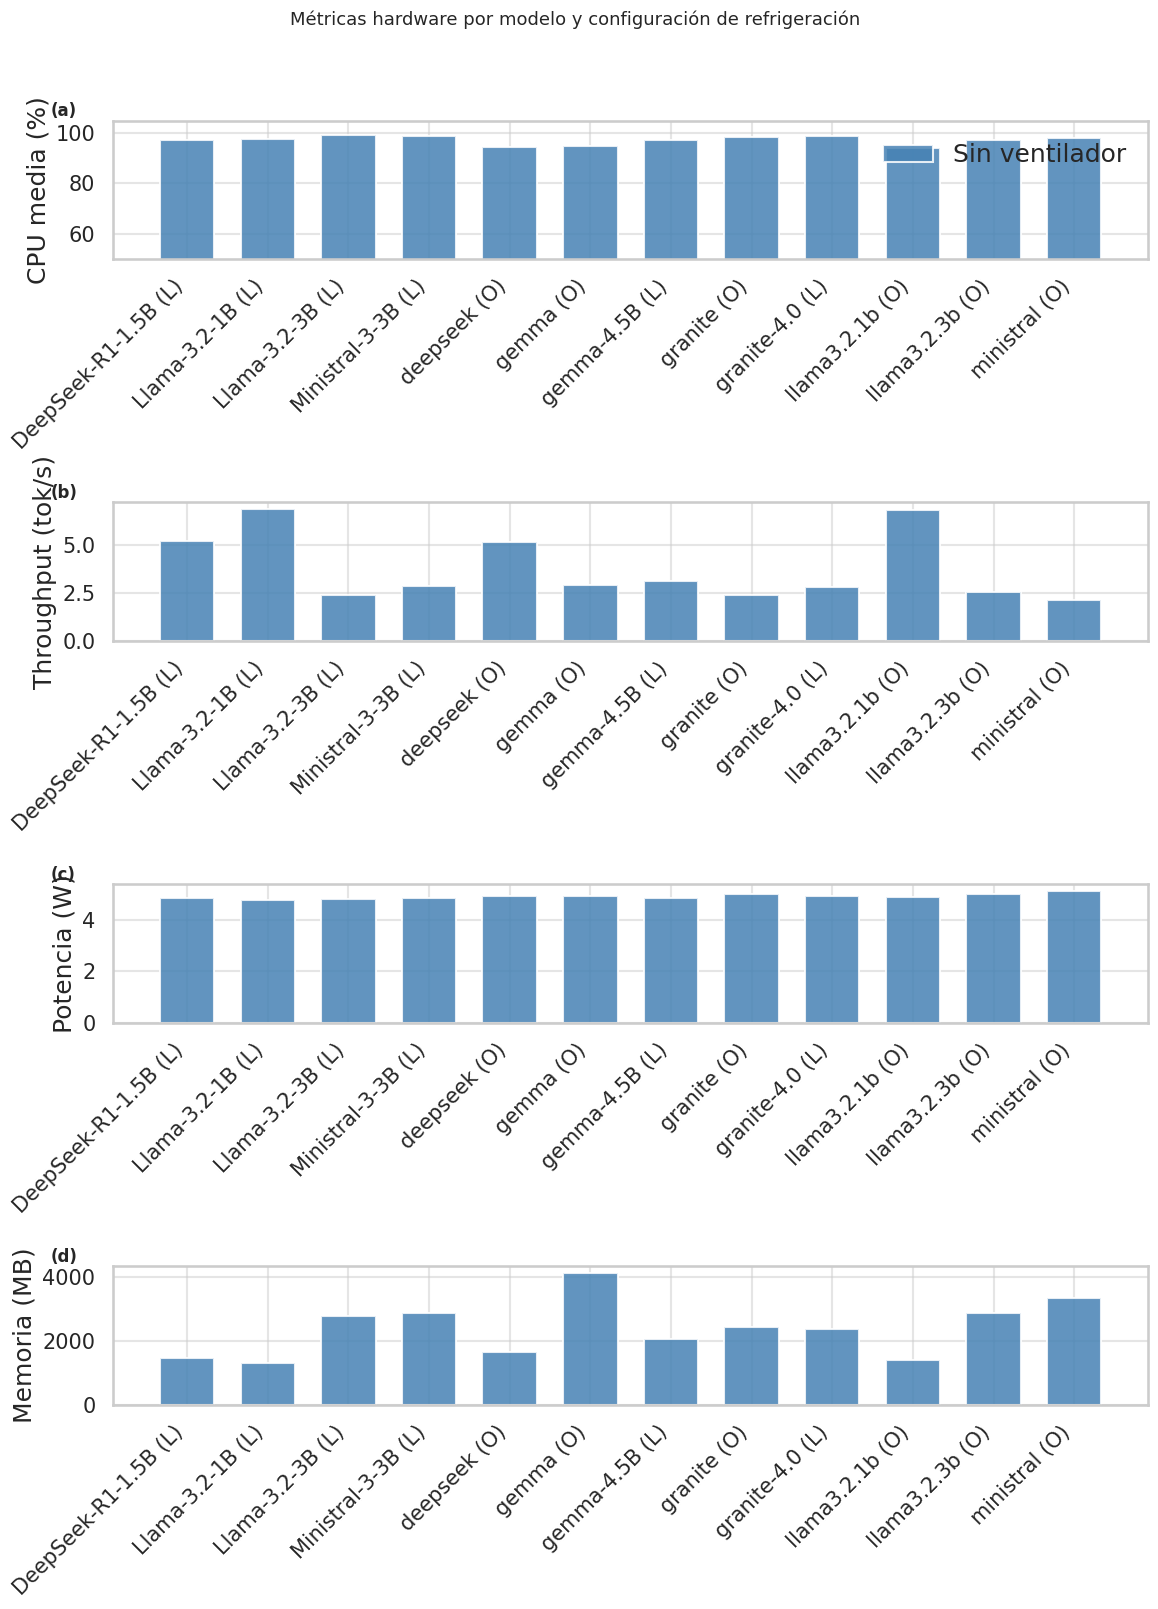

In [9]:
import re
import numpy as np

def _plot_label(model_short: str, engine: str) -> str:
    """Abbreviate model name for axis labels."""
    name = model_short
    name = re.sub(r'-Q\d_K_[MS].*', '', name)       # -Q4_K_M suffix
    name = re.sub(r':q\d_k_[ms]$', '', name)         # :q4_k_m suffix
    name = re.sub(r'-Instruct', '', name)
    name = re.sub(r'-2512', '', name)
    name = re.sub(r'-Distill-Qwen', '', name)
    name = re.sub(r'-3n-E2B-it', '', name)           # gemma specific
    name = re.sub(r'-h-micro', '', name)              # granite specific
    name = re.sub(r'_', '.', name)
    name = name.strip('-')
    suffix = "O" if engine == "OLLAMA" else "L"
    return f"{name} ({suffix})"

# Agregar métricas hw por run
hw_full = coll.hw_metrics_df()
pm_full = coll.prompt_metrics_df()

hw_summary_rows = []
for r in coll.runs:
    hw_r = hw_full[hw_full["run_id"] == r.run_id]
    pm_r = pm_full[
        (pm_full["run_id"] == r.run_id) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ]
    if hw_r.empty:
        continue
    active = hw_r[hw_r["cpu_usage_pct"] > 50]
    fan_label = "Con ventilador" if r.meta.fan else "Sin ventilador"
    hw_summary_rows.append({
        "model":    _plot_label(r.model_short, r.summary.inference_engine),
        "config":   fan_label,
        "cpu_pct":  active["cpu_usage_pct"].mean() if not active.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w":  hw_r["internal_power_w"].mean(),
        "mem_mb":   (hw_r["mem_used_bytes"].mean() / (1024**2)) if not hw_r.empty else float("nan"),
    })

hw_summary = pd.DataFrame(hw_summary_rows)

METRICS = [
    ("cpu_pct",   "CPU media (%)",      "(a)", (50, 105)),
    ("tokens_s",  "Throughput (tok/s)", "(b)", None),
    ("power_w",   "Potencia (W)",       "(c)", None),
    ("mem_mb",    "Memoria (MB)",       "(d)", None),
]

models  = sorted(hw_summary["model"].unique())
configs = sorted(hw_summary["config"].unique())
colors  = ["steelblue", "tomato", "seagreen", "goldenrod"]
x_pos   = np.arange(len(models))
n_cfg   = len(configs)
width   = 0.75 / max(n_cfg, 1)

fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 4 * len(METRICS)))
if len(METRICS) == 1:
    axes = [axes]

for ax, (col, ylabel, label, ylim) in zip(axes, METRICS):
    data = hw_summary.dropna(subset=[col])
    for i, (cfg, color) in enumerate(zip(configs, colors)):
        vals = []
        for m in models:
            sub = data[(data["model"] == m) & (data["config"] == cfg)]
            vals.append(sub[col].mean() if not sub.empty else float("nan"))
        offset = (i - n_cfg / 2 + 0.5) * width
        ax.bar(x_pos + offset, vals, width * 0.9,
               label=cfg, color=color, alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.text(-0.06, 1.03, label, transform=ax.transAxes,
            fontweight="bold", fontsize=12)
    if col == "cpu_pct":
        ax.legend(loc="upper right")

fig.suptitle(
    "Métricas hardware por modelo y configuración de refrigeración",
    y=1.01, fontsize=13,
)
fig.tight_layout()
plt.show()
